In [1]:
import healpy as hp
import healpy
from jax_healpy import pixelfunc as jhp
import numpy as np
import jax
import jax.numpy as jnp
import jax.nn as jnn
import optax
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
import hera_filters as hf
from functools import partial
import scipy
# %matplotlib widget

In [2]:
def rot_m(ang, vec):
    """Return 3x3 matrix defined by rotation by 'ang' around the
    axis 'vec', according to the right-hand rule.  Both can be vectors,
    returning a vector of rotation matrices.  Rotation matrix will have a
    scaling of |vec| (i.e. normalize |vec|=1 for a pure rotation)."""
    c = jnp.cos(ang); s = jnp.sin(ang); C = 1-c
    # vec = vec/jnp.linalg.norm(vec, axis=-1, keepdims=True) # just added
    x,y,z = vec[...,0], vec[...,1], vec[...,2]
    xs,ys,zs = x*s, y*s, z*s
    xC,yC,zC = x*C, y*C, z*C
    xyC,yzC,zxC = x*yC, y*zC, z*xC
    rm = jnp.array([[x*xC+c, xyC-zs, zxC+ys],
                   [xyC+zs, y*yC+c, yzC-xs],
                   [zxC-ys, yzC+xs, z*zC+c]], dtype=jnp.double)
    if rm.ndim > 2:
        axes = list(range(rm.ndim))
        return rm.transpose(axes[-1:] + axes[:-1])
    else:
        return rm


def xyz2thphi(xyz, *, dtype=jnp.float64, return_mask=False, masked_fill=0.0):
    """
    Convert xyz vectors (x,y,z along first axis) into angles:
      theta (from +z), phi (counter-clockwise around +z, 0 at +x).

    - Accepts regular arrays or np.ma.MaskedArray.
    - If masked input is given (mask taken from x), masked elements are
      treated as `masked_fill` during the computation (default 0.0),
      which matches the original `.filled(0)` behavior.
    - Returns a JAX array shaped (2, ...): [theta, phi].
    - If `return_mask=True`, also returns a boolean mask shaped (2, ...),
      equal to [x.mask, x.mask] when a mask exists, else all False.
    """
    x, y, z = xyz

    # Detect masked arrays and normalize inputs
    x_is_ma = isinstance(x, np.ma.MaskedArray)
    if x_is_ma:
        # Use x's mask like the original function
        in_mask = jnp.asarray(getattr(x, "mask", False))
        # Compute with masked values filled as zeros (or masked_fill)
        x = np.ma.filled(x, masked_fill)
        y = np.ma.filled(y, masked_fill)
        z = np.ma.filled(z, masked_fill)
    else:
        in_mask = None

    # Convert to JAX arrays
    x = jnp.asarray(x)
    y = jnp.asarray(y)
    z = jnp.asarray(z)

    # More stable than sqrt(x**2 + y**2)
    r   = jnp.hypot(x, y)
    phi = jnp.arctan2(y, x)
    th  = jnp.arctan2(r, z)

    out = jnp.stack([th, phi]).astype(dtype)

    if return_mask:
        if in_mask is None:
            mask = jnp.zeros_like(x, dtype=bool)
        else:
            mask = jnp.asarray(in_mask, dtype=bool)
        # Propagate the mask to both rows: [x.mask, x.mask]
        mask = jnp.broadcast_to(mask, x.shape)
        mask = jnp.stack([mask, mask])
        return out, mask

    return out

dtype_r = jnp.float64
DEFAULT_NSIDE = 32
# DEFAULT_NSIDE = 64
# DEFAULT_NSIDE = 16
# DEFAULT_NSIDE = 8
# DEFAULT_NSIDE = 128
DEFAULT_NPIX = healpy.nside2npix(DEFAULT_NSIDE)
px = jnp.arange(DEFAULT_NPIX)
th, phi = healpy.pix2ang(DEFAULT_NSIDE, px)
DEFAULT_BEAM_TH = jnp.cos(th)**2 * jnp.cos(phi)**2
DEFAULT_BEAM_PHI = jnp.cos(th)**2 * jnp.sin(phi)**2

In [3]:
from datetime import datetime, timezone
from zoneinfo import ZoneInfo
import os
mtn_tzone = ZoneInfo("America/Denver")

t_start = datetime(2025, 7, 20, 13, 11, 51, 774738, tzinfo=mtn_tzone)
t_stop =  datetime(2025, 7, 20, 14, 35, 41, 181442, tzinfo=mtn_tzone)
def unix_time_to_local(unix_times):
    local_times = np.array([datetime.fromtimestamp(ts, tz=timezone.utc).astimezone(mtn_tzone) for ts in unix_times])
    return local_times

In [4]:
npz_file = '/Users/dominiv/eigsep/data/all_ant_2.npz'
# dtype_r = np.float32
dtype_c = np.complex64
if not os.path.exists(npz_file):
    data = {}
    times = []
    for f in files:
        print(f)
        hdr = read_header(f)
        if unix_time_to_local(hdr['times'][-1:]) < t_start:
            continue
        if unix_time_to_local(hdr['times'][:1]) > t_stop:
            continue
        dat, hdr, meta = io.read_hdf5(f)
        times.append(hdr['times'])
        for k in dat.keys():
            _d = dat[k]
            data[k] = data.get(k, []) + [_d]
    for k, v in data.items():
        data[k] = np.concatenate(v, dtype=dtype_r if len(k) == 1 else dtype_c)
    times = np.concatenate(times)
    local_times = unix_time_to_local(times)
    np.savez(npz_file, times=times, local_times=local_times, freqs=freqs, **data)
else:
    npz = np.load(npz_file, allow_pickle=True)
    data = {k: npz[k] for k in npz.files}
    times = data.pop('times')
    local_times = data.pop('local_times')
    freqs = data.pop('freqs')

In [5]:
chs = np.arange(16, 1024, 16)
k_1 = '2'
reduced = data[k_1][:, chs]
reduced = data[k_1][:,chs] - 0.5 * (data[k_1][:,chs-1] + data[k_1][:,chs+1])

In [6]:
f_ind = 44
# f_ind = 52
# f_ind = 61
ch = f_ind
AZ_STEPS = 72  # with endpoint=True
period = 68.78
#t_start = 1753038750 # s utc
t_start = 1753038750 + period/2 # s utc
# t_start = times[0] + period/2 # s utc
t_cut = [(1753039060, 1753039181), (1753042808, 1753042834), (1753043111, 1753043119)]  # junk data
i_start = np.searchsorted(times, t_start)
norm = 1 / np.mean(reduced[:i_start], axis=0, keepdims=True)
norm[:,:4] = 0
t_stop = t_start + AZ_STEPS * period
i_stop = np.searchsorted(times, t_stop)

valid = np.ones(times.shape, dtype=bool)
valid = np.where(reduced[:,52] * norm[:,52] < 1e-4, False, ~np.isnan(reduced[:,52]))
for ti, tj in t_cut:
    i, j = np.searchsorted(times, ti), np.searchsorted(times, tj)
    valid[i:j] = False
    
valid[1:-1] = np.logical_and(valid[1:-1], np.logical_and(valid[:-2], valid[2:]))
sl = slice(i_start, i_stop)
_times = times[sl].copy()
_times -= _times[0]
# optional for strictly data-driven double-period folding
#_times_rnd = np.floor(_times / (2 * period))
#_times_mod = _times - _times_rnd * (2 * period)
val = valid[sl]
print(freqs[::16][ch])

171.875


In [7]:
import aipy
class BeamFit:
    def __init__(self, times, az_steps=AZ_STEPS, lmax=5):
        self.az_steps = az_steps
        self.times = times
        self.lmax = lmax
        self._el_ax = self._ant_pvec = np.array([1, 0, 0], dtype=dtype_r)
        self._az_ax = np.array([0, 0, -1], dtype=dtype_r)
        self.prms = {}
        self.ant_pvec = self.polresp = self.A_Ylm = self.A = None

    def _set_timing_params(self, prms):
        keys = {'t_off', 'el_off', 't_az_step', 'period'}
        for k in keys:
            if k in prms and prms[k] != self.prms.get(k, None):
                self.prms[k] = prms[k]
                self.az_deg = self.el_deg = self.ant_pvec = self.A_Ylm = self.A = None

    def _set_pol_params(self, prms):
        keys = {'prz', 'px', 'py'}
        for k in keys:
            if k in prms and prms[k] != self.prms.get(k, None):
                self.prms[k] = prms[k]
                self.gnd_pvecs = self.polresp = self.A = None

    def set_params(self, prms):
        self._set_timing_params(prms)
        self._set_pol_params(prms)
        
    def build_az_el(self):
        '''Build az/el coordinates.'''
        if self.ant_pvec is not None:
            return
        az, el, inds = [], [], []
        t_off, el_off, t_az_step, period = self.prms['t_off'], self.prms['el_off'], self.prms['t_az_step'], self.prms['period']
        i = 0
        t_i = self.times[0] + t_off
        for cnt, _az in enumerate(np.linspace(-180, 180, self.az_steps, endpoint=True)):
            t_f = t_i + period
            while i < self.times.size and self.times[i] < t_f - t_az_step:
                az.append(_az)
                if cnt % 2 == 0:
                    el.append(-180 + 360 * (self.times[i] - t_i) / (period - t_az_step))
                else:
                    el.append( 180 - 360 * (self.times[i] - t_i) / (period - t_az_step))
                inds.append(i)
                i += 1
            while i < self.times.size and self.times[i] < t_f:
                az.append(_az + (360 / (self.az_steps - 1)) * (self.times[i] - (t_f - t_az_step))/t_az_step)
                el.append(el[-1])
                inds.append(i)
                i += 1
            t_i = t_f
        self.az_deg = np.array(az)
        self.el_deg = np.array(el) + el_off
        self.inds = np.array(inds)
        rot_az = aipy.coord.rot_m(np.deg2rad(self.az_deg), self._az_ax)
        rot_el = aipy.coord.rot_m(np.deg2rad(self.el_deg), self._el_ax)
        self.ant_pvec = np.einsum('pab,pbc,c->pa', rot_el, rot_az, self._ant_pvec)

    


    
    def build_pol_resp(self):
        self.build_az_el()
        if self.polresp is not None:
            return
        pvec = np.array([[self.prms['px'], 0, 0], [0, self.prms['py'], 0]], dtype=dtype_r)
        rot_m = aipy.coord.rot_m(np.deg2rad(self.prms['prz']), np.array([0, 0, 1])).astype(dtype_r)
        self.gnd_pvecs = np.dot(rot_m, pvec.T).T
        if self.gnd_pvecs.ndim == 1:
            self.gnd_pvecs = self.gnd_pvecs[None, :]
        resp = np.dot(self.ant_pvec, self.gnd_pvecs.T)
        self.polresp = np.sum(np.abs(resp)**2, axis=-1)

    def build_A_Ylm(self):
        self.build_az_el()
        if self.A_Ylm is not None:
            return
        phi = np.deg2rad(self.az_deg)
        theta = np.deg2rad(self.el_deg)
        theta = np.mod(theta, 2*np.pi)
        theta = np.where(theta > np.pi, 2*np.pi - theta, theta)
        phi = np.mod(phi, 2*np.pi)
    
        N = theta.size
        P = (self.lmax + 1)**2
        A = np.empty((N, P), dtype=dtype_r)
    
        # Keep track of which column corresponds to which (l,m,kind)
        # kind ∈ {'m0','c','s'} for m=0, cos-like, sin-like
        self._meta = []
        col = 0
        for ell in range(self.lmax + 1):
            # m = 0 term (purely real)
            Y_l0 = sph_harm(0, ell, phi, theta).real
            #Y_l0 *= gen_pol_resp(az_deg, el_deg, gnd_pvecs)
            A[:, col] = Y_l0
            self._meta.append((ell, 0, 'm0'))
            col += 1
    
            # m > 0 terms: sqrt(2)*Re and sqrt(2)*Im
            for m in range(1, ell + 1):
                Y_lm = sph_harm(m, ell, phi, theta)  # complex
                #Y_lm *= gen_pol_resp(az_deg, el_deg, gnd_pvecs)
                A[:, col] = SQRT2 * Y_lm.real
                A[:, col+1] = SQRT2 * Y_lm.imag
                self._meta.append((ell, m, 'c'))
                self._meta.append((ell, m, 's'))
                col += 2
    
        assert col == P
        self.A_Ylm = A

    def build_A(self):
        self.build_pol_resp()
        self.build_A_Ylm()
        if self.A is not None:
            return
        self.A = self.A_Ylm * self.polresp[:, None]

    def _realcoeff_to_alm(self, coeff):
        """
        Convert real-basis coeffficients (matching design-matrix columns) into a
        healpy alm array (complex, m>=0). For a real sky, alms obey:
          a_{l,-m} = (-1)^m a_{l m}^*
        We only fill m>=0 as healpy expects.
        """
        alm = np.zeros(Alm.getsize(self.lmax), dtype=dtype_c)
        for k, (ell, m, kind) in enumerate(self._meta):
            if m == 0 and kind == 'm0':
                alm[Alm.getidx(self.lmax, ell, 0)] = coeff[k]
            elif kind in ('c'):
                c = coeff[k]
                s = coeff[k + 1]
                a_lm = (c - 1j * s) / SQRT2
                alm[Alm.getidx(self.lmax, ell, m)] = a_lm
        return alm

    def fit_alms(self, ymeas, w=None, reg=None, rcond=1e-10):
        self.build_A()
    
        # Apply weights (as sqrt weights on rows)
        ymeas = ymeas[self.inds]
        if w is None:
            w = np.ones_like(ymeas)
        else:
            w = w[self.inds]
        sqrtw = np.sqrt(w)
        Aw = self.A * sqrtw[:, None]
        yw = ymeas * sqrtw
    
        # Optional ridge regularization: stack sqrt(reg)*I
        if reg is not None and reg > 0:
            P = self.A.shape[1]
            Aw = np.vstack([Aw, np.sqrt(reg) * np.eye(P)])
            yw = np.concatenate([yw, np.zeros(P)])
    
        coeff = np.linalg.lstsq(Aw[self.inds], yw[self.inds], rcond=rcond)[0]
        yhat = self.A @ coeff
        chisq = np.sum(w * (ymeas[self.inds] - yhat[self.inds])**2)
        alm = self._realcoeff_to_alm(coeff)
        return alm, chisq, yhat

In [8]:
t_az_step = 1.7
prms = dict(
    t_az_step = t_az_step, # XXX degenerate with beam width, need empirical measurement
    t_off = -2.4 + t_az_step/2,
    # t_off = -2.0 + t_az_step/2,
    el_off = -4.0,  # shift for pol_ang=62 on ch=44, seems to work for the rest. XXX degenerate with t_off?
    # el_off = -8.5,  # shift for pol_ang=62 on ch=44, seems to work for the rest. XXX degenerate with t_off?
    # az_off is unnecessary given fitting of polarization angle
    prz = 0.0,
    px = 1.0,
    py = 0.0,
    period = period,
)

# # force a rebuild
# fitter.ant_pvec = None
# fitter.az_deg = None
# fitter.el_deg = None
# fitter.A_Ylm = None
# fitter.A = None
# fitter.build_az_el()

fitter = BeamFit(_times[val])
fitter.set_params(prms)
fitter.build_az_el()

In [9]:
shift = 12
rot = reduced[:, shift:][sl][val][fitter.inds] #* norm[:, ch]
norm = norm[:, shift:]
outfile = 'figures/'
print(rot.shape, norm.shape)

(4409, 51) (1, 51)


In [19]:
beam_maps_th = np.load('/Users/dominiv/eigsep/data/beam_th.npy')[:-1, :] # recent note: we go from 50 to 250, but the channels we actually use are from 50 tp 247ish, so we need to shave off the last channel
beam_maps_ph = np.load('/Users/dominiv/eigsep/data/beam_ph.npy')[:-1, :] # recent note: we go from 50 to 250, but the channels we actually use are from 50 tp 247ish, so we need to shave off the last channel
print(beam_maps_ph.shape, beam_maps_th.shape)
# m_th =  beam_maps_th[ch-13] # offset by 13 due to freqs starting from 0, we start at 50
# m_phi = beam_maps_ph[ch-13] # recent note: not sure what i meant from above, it should be the data we shift
m_th =  beam_maps_th[ch] # offset by 13 due to freqs starting from 0, we start at 50
m_phi = beam_maps_ph[ch] # recent note: not sure what i meant from above, it should be the data we shift
az_inds = np.deg2rad(fitter.az_deg[fitter.inds])
el_inds = np.deg2rad(fitter.el_deg[fitter.inds])

(51, 12288) (51, 12288)


In [11]:
s11_transmitter = np.loadtxt(   '/Users/dominiv/research/data/S11_Transmitter.csv', delimiter=',', skiprows=1)
s11_aut = np.loadtxt( '/Users/dominiv/research/data/S11_AUT.csv', delimiter=',', skiprows=1)
s12_atu_t = np.loadtxt('/Users/dominiv/research/data/S12_AUT_to_Trans.csv', delimiter=',', skiprows=1)
inc = 201
ang = 361
print(s11_transmitter.shape)

(72561, 4)


In [12]:
bowtie_theta_gain_100 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Bowtie_LinearScale/RGP_THETA_100MHz.csv', delimiter=',', skiprows=1)
bowtie_theta_gain_150 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Bowtie_LinearScale/RGP_THETA_150MHz.csv', delimiter=',', skiprows=1)
bowtie_theta_gain_200 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Bowtie_LinearScale/RGP_THETA_200MHz.csv', delimiter=',', skiprows=1)
bowtie_theta_gain_250 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Bowtie_LinearScale/RGP_THETA_250MHz.csv', delimiter=',', skiprows=1)

bowtie_phi_gain_100 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Bowtie_LinearScale/RGP_PHI_100MHz.csv', delimiter=',', skiprows=1)
bowtie_phi_gain_150 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Bowtie_LinearScale/RGP_PHI_150MHz.csv', delimiter=',', skiprows=1)
bowtie_phi_gain_200 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Bowtie_LinearScale/RGP_PHI_200MHz.csv', delimiter=',', skiprows=1)
bowtie_phi_gain_250 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Bowtie_LinearScale/RGP_PHI_250MHz.csv', delimiter=',', skiprows=1)

bowtie_x_gain_100 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Bowtie_LinearScale/RGP_X_100MHz.csv', delimiter=',', skiprows=1)
bowtie_x_gain_150 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Bowtie_LinearScale/RGP_X_150MHz.csv', delimiter=',', skiprows=1)
bowtie_x_gain_200 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Bowtie_LinearScale/RGP_X_200MHz.csv', delimiter=',', skiprows=1)
bowtie_x_gain_250 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Bowtie_LinearScale/RGP_X_250MHz.csv', delimiter=',', skiprows=1)

bowtie_y_gain_100 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Bowtie_LinearScale/RGP_Y_100MHz.csv', delimiter=',', skiprows=1)
bowtie_y_gain_150 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Bowtie_LinearScale/RGP_Y_150MHz.csv', delimiter=',', skiprows=1)
bowtie_y_gain_200 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Bowtie_LinearScale/RGP_Y_200MHz.csv', delimiter=',', skiprows=1)
bowtie_y_gain_250 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Bowtie_LinearScale/RGP_Y_250MHz.csv', delimiter=',', skiprows=1)

bowtie_z_gain_100 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Bowtie_LinearScale/RGP_Z_100MHz.csv', delimiter=',', skiprows=1)
bowtie_z_gain_150 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Bowtie_LinearScale/RGP_Z_150MHz.csv', delimiter=',', skiprows=1)
bowtie_z_gain_200 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Bowtie_LinearScale/RGP_Z_200MHz.csv', delimiter=',', skiprows=1)
bowtie_z_gain_250 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Bowtie_LinearScale/RGP_Z_250MHz.csv', delimiter=',', skiprows=1)

dipole_theta_gain_100 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Dipole_LinearScale/RGP_THETA_100MHz.csv', delimiter=',', skiprows=1)
dipole_theta_gain_150 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Dipole_LinearScale/RGP_THETA_150MHz.csv', delimiter=',', skiprows=1)
dipole_theta_gain_200 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Dipole_LinearScale/RGP_THETA_200MHz.csv', delimiter=',', skiprows=1)
dipole_theta_gain_250 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Dipole_LinearScale/RGP_THETA_250MHz.csv', delimiter=',', skiprows=1)

dipole_phi_gain_100 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Dipole_LinearScale/RGP_PHI_100MHz.csv', delimiter=',', skiprows=1)
dipole_phi_gain_150 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Dipole_LinearScale/RGP_PHI_150MHz.csv', delimiter=',', skiprows=1)
dipole_phi_gain_200 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Dipole_LinearScale/RGP_PHI_200MHz.csv', delimiter=',', skiprows=1)
dipole_phi_gain_250 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Dipole_LinearScale/RGP_PHI_250MHz.csv', delimiter=',', skiprows=1)

dipole_theta_imag_100 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/100MHz/rE_Theta_Imaginaryl_100MHz.csv', delimiter=',', skiprows=1)
dipole_theta_real_100 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/100MHz/rE_Theta_Real_100MHz.csv', delimiter=',', skiprows=1)
dipole_phi_imag_100 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/100MHz/rE_Phi_Imaginary_100MHz.csv', delimiter=',', skiprows=1)
dipole_phi_real_100 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/100MHz/rE_Phi_Real_100MHz.csv', delimiter=',', skiprows=1)
dipole_theta_imag_150 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/150MHz/rE_Theta_Imaginary_150MHz.csv', delimiter=',', skiprows=1)
dipole_theta_real_150 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/150MHz/rE_Theta_Real_150MHz.csv', delimiter=',', skiprows=1)
dipole_phi_imag_150 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/150MHz/rE_Phi_Imaginary_150MHz.csv', delimiter=',', skiprows=1)
dipole_phi_real_150 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/150MHz/rE_Phi_Real_150MHz.csv', delimiter=',', skiprows=1)
dipole_theta_imag_200 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/200MHz/rE_Theta_Imaginary_200MHz.csv', delimiter=',', skiprows=1)
dipole_theta_real_200 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/200MHz/rE_Theta_Real_200MHz.csv', delimiter=',', skiprows=1)
dipole_phi_imag_200 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/200MHz/rE_Phi_Imaginary_200MHz.csv', delimiter=',', skiprows=1)
dipole_phi_real_200 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/200MHz/rE_Phi_Real_200MHz.csv', delimiter=',', skiprows=1)
dipole_theta_imag_250 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/250MHz/rE_Theta_Imaginary_250MHz.csv', delimiter=',', skiprows=1)
dipole_theta_real_250 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/250MHz/rE_Theta_Real_250MHz.csv', delimiter=',', skiprows=1)
dipole_phi_imag_250 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/250MHz/rE_Phi_Imaginary_250MHz.csv', delimiter=',', skiprows=1)
dipole_phi_real_250 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/250MHz/rE_Phi_Real_250MHz.csv', delimiter=',', skiprows=1)

dipole_x_gain_100 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Dipole_LinearScale/RGP_X_100MHz.csv', delimiter=',', skiprows=1)
dipole_x_gain_150 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Dipole_LinearScale/RGP_X_150MHz.csv', delimiter=',', skiprows=1)
dipole_x_gain_200 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Dipole_LinearScale/RGP_X_200MHz.csv', delimiter=',', skiprows=1)
dipole_x_gain_250 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Dipole_LinearScale/RGP_X_250MHz.csv', delimiter=',', skiprows=1)

dipole_y_gain_100 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Dipole_LinearScale/RGP_Y_100MHz.csv', delimiter=',', skiprows=1)
dipole_y_gain_150 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Dipole_LinearScale/RGP_Y_150MHz.csv', delimiter=',', skiprows=1)
dipole_y_gain_200 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Dipole_LinearScale/RGP_Y_200MHz.csv', delimiter=',', skiprows=1)
dipole_y_gain_250 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Dipole_LinearScale/RGP_Y_250MHz.csv', delimiter=',', skiprows=1)

dipole_z_gain_100 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Dipole_LinearScale/RGP_Z_100MHz.csv', delimiter=',', skiprows=1)
dipole_z_gain_150 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Dipole_LinearScale/RGP_Z_150MHz.csv', delimiter=',', skiprows=1)
dipole_z_gain_200 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Dipole_LinearScale/RGP_Z_200MHz.csv', delimiter=',', skiprows=1)
dipole_z_gain_250 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Dipole_LinearScale/RGP_Z_250MHz.csv', delimiter=',', skiprows=1)

### check file names, i think i messed some up
bowtie_theta_imag_100 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/100MHz/rE_Theta_Imaginary_100MHz.csv', delimiter=',', skiprows=1)
bowtie_theta_real_100 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/100MHz/rE_Theta_Real_100MHz.csv', delimiter=',', skiprows=1)
bowtie_phi_imag_100 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/100MHz/rE_Phi_Imaginary_100MHz.csv', delimiter=',', skiprows=1)
bowtie_phi_real_100 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/100MHz/rE_Phi_Real_100MHz.csv', delimiter=',', skiprows=1)
bowtie_theta_imag_150 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/150MHz/rE_Theta_Imaginary_150MHz.csv', delimiter=',', skiprows=1)
bowtie_theta_real_150 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/150MHz/rE_Theta_Real_150MHz.csv', delimiter=',', skiprows=1)
bowtie_phi_imag_150 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/150MHz/rE_Phi_Imaginary_150MHz.csv', delimiter=',', skiprows=1)
bowtie_phi_real_150 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/150MHz/rE_Phi_Real_150MHz.csv', delimiter=',', skiprows=1)
bowtie_theta_imag_200 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/200MHz/rE_Theta_Imaginary_200MHz.csv', delimiter=',', skiprows=1)
bowtie_theta_real_200 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/200MHz/rE_Theta_Real_200MHz.csv', delimiter=',', skiprows=1)
bowtie_phi_imag_200 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/200MHz/rE_Phi_Imaginary_200MHz.csv', delimiter=',', skiprows=1)
bowtie_phi_real_200 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/200MHz/rE_Phi_Real_200MHz.csv', delimiter=',', skiprows=1)
bowtie_theta_imag_250 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/250MHz/rE_Theta_Imaginary_250MHz.csv', delimiter=',', skiprows=1)
bowtie_theta_real_250 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/250MHz/rE_Theta_Real_250MHz.csv', delimiter=',', skiprows=1)
bowtie_phi_imag_250 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/250MHz/rE_Phi_Imaginary_250MHz.csv', delimiter=',', skiprows=1)
bowtie_phi_real_250 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/250MHz/rE_Phi_Real_250MHz.csv', delimiter=',', skiprows=1)

dipole_xr_gain_100 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/100MHz/rE_X_Real_100MHz.csv', delimiter=',', skiprows=1)
dipole_xi_gain_100 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/100MHz/rE_X_Imaginary_100MHz.csv', delimiter=',', skiprows=1)
dipole_yr_gain_100 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/100MHz/rE_Y_Real_100MHz.csv', delimiter=',', skiprows=1)
dipole_yi_gain_100 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/100MHz/rE_Y_Imaginary_100MHz.csv', delimiter=',', skiprows=1)
dipole_zr_gain_100 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/100MHz/rE_Z_Real_100MHz.csv', delimiter=',', skiprows=1)
dipole_zi_gain_100 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/100MHz/rE_Z_Imaginary_100MHz.csv', delimiter=',', skiprows=1)

bowtie_xr_gain_100 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/100MHz/rE_X_Real_100MHz.csv', delimiter=',', skiprows=1)
bowtie_xi_gain_100 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/100MHz/rE_X_Imaginary_100MHz.csv', delimiter=',', skiprows=1)
bowtie_yr_gain_100 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/100MHz/rE_Y_Real_100MHz.csv', delimiter=',', skiprows=1)
bowtie_yi_gain_100 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/100MHz/rE_Y_Imaginary_100MHz.csv', delimiter=',', skiprows=1)
bowtie_zr_gain_100 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/100MHz/rE_Z_Real_100MHz.csv', delimiter=',', skiprows=1)
bowtie_zi_gain_100 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/100MHz/rE_Z_Imaginary_100MHz.csv', delimiter=',', skiprows=1)

dipole_xr_gain_200 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/200MHz/rE_X_Real_200MHz.csv', delimiter=',', skiprows=1)
dipole_xi_gain_200 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/200MHz/rE_X_Imaginary_200MHz.csv', delimiter=',', skiprows=1)
dipole_yr_gain_200 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/200MHz/rE_Y_Real_200MHz.csv', delimiter=',', skiprows=1)
dipole_yi_gain_200 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/200MHz/rE_Y_Imaginary_200MHz.csv', delimiter=',', skiprows=1)
dipole_zr_gain_200 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/200MHz/rE_Z_Real_200MHz.csv', delimiter=',', skiprows=1)
dipole_zi_gain_200 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/200MHz/rE_Z_Imaginary_200MHz.csv', delimiter=',', skiprows=1)

bowtie_xr_gain_200 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/200MHz/rE_X_Real_200MHz.csv', delimiter=',', skiprows=1)
bowtie_xi_gain_200 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/200MHz/rE_X_Imaginary_200MHz.csv', delimiter=',', skiprows=1)
bowtie_yr_gain_200 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/200MHz/rE_Y_Real_200MHz.csv', delimiter=',', skiprows=1)
bowtie_yi_gain_200 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/200MHz/rE_Y_Imaginary_200MHz.csv', delimiter=',', skiprows=1)
bowtie_zr_gain_200 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/200MHz/rE_Z_Real_200MHz.csv', delimiter=',', skiprows=1)
bowtie_zi_gain_200 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/200MHz/rE_Z_Imaginary_200MHz.csv', delimiter=',', skiprows=1)

dipole_xr_gain_250 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/250MHz/rE_X_Real_250MHz.csv', delimiter=',', skiprows=1)
dipole_xi_gain_250 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/250MHz/rE_X_Imaginary_250MHz.csv', delimiter=',', skiprows=1)
dipole_yr_gain_250 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/250MHz/rE_Y_Real_250MHz.csv', delimiter=',', skiprows=1)
dipole_yi_gain_250 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/250MHz/rE_Y_Imaginary_250MHz.csv', delimiter=',', skiprows=1)
dipole_zr_gain_250 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/250MHz/rE_Z_Real_250MHz.csv', delimiter=',', skiprows=1)
dipole_zi_gain_250 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Dipole_LinearScale/250MHz/rE_Z_Imaginary_250MHz.csv', delimiter=',', skiprows=1)

bowtie_xr_gain_250 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/250MHz/rE_X_Real_250MHz.csv', delimiter=',', skiprows=1)
bowtie_xi_gain_250 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/250MHz/rE_X_Imaginary_250MHz.csv', delimiter=',', skiprows=1)
bowtie_yr_gain_250 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/250MHz/rE_Y_Real_250MHz.csv', delimiter=',', skiprows=1)
bowtie_yi_gain_250 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/250MHz/rE_Y_Imaginary_250MHz.csv', delimiter=',', skiprows=1)
bowtie_zr_gain_250 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/250MHz/rE_Z_Real_250MHz.csv', delimiter=',', skiprows=1)
bowtie_zi_gain_250 = np.loadtxt('/Users/dominiv/research/data/complex/Electric Field Patterns_Bowtie_LinearScale/250MHz/rE_Z_Imaginary_250MHz.csv', delimiter=',', skiprows=1)

nside = DEFAULT_NSIDE
npix = hp.nside2npix(nside)
beam_thetas = np.deg2rad(bowtie_x_gain_100[:, 1])
beam_phis =   np.deg2rad(bowtie_x_gain_100[:, 0])

def hfss_map(gain, k=8):
    sample_vec = np.asarray(hp.ang2vec(beam_thetas, beam_phis))
    if sample_vec.shape[0] == 3 and sample_vec.ndim == 2:
        sample_vec = sample_vec.T
    
    tree = cKDTree(sample_vec)
    
    pix_vec = np.asarray(hp.pix2vec(nside, np.arange(npix))).T
    
    # k = 8
    dist, idx = tree.query(pix_vec, k=k)
    
    if k == 1:
        dist = dist[:, None]
        idx = idx[:, None]
    
    eps = 1e-12
    w = 1.0 / (dist + eps)**2
    w /= w.sum(axis=1, keepdims=True)
    
    hmap = (w * gain[:, 2][idx]).sum(axis=1)
    return hmap


# ek = 1
ek = 8

bowtie_x_beam_100 = hfss_map(bowtie_x_gain_100)
bowtie_x_beam_150 = hfss_map(bowtie_x_gain_150)
bowtie_x_beam_200 = hfss_map(bowtie_x_gain_200)
bowtie_x_beam_250 = hfss_map(bowtie_x_gain_250)

bowtie_y_beam_100 = hfss_map(bowtie_y_gain_100)
bowtie_y_beam_150 = hfss_map(bowtie_y_gain_150)
bowtie_y_beam_200 = hfss_map(bowtie_y_gain_200)
bowtie_y_beam_250 = hfss_map(bowtie_y_gain_250)

bowtie_z_beam_100 = hfss_map(bowtie_z_gain_100)
bowtie_z_beam_150 = hfss_map(bowtie_z_gain_150)
bowtie_z_beam_200 = hfss_map(bowtie_z_gain_200)
bowtie_z_beam_250 = hfss_map(bowtie_z_gain_250)

dipole_x_beam_100 = hfss_map(dipole_x_gain_100)
dipole_x_beam_150 = hfss_map(dipole_x_gain_150)
dipole_x_beam_200 = hfss_map(dipole_x_gain_200)
dipole_x_beam_250 = hfss_map(dipole_x_gain_250)

dipole_y_beam_100 = hfss_map(dipole_y_gain_100)
dipole_y_beam_150 = hfss_map(dipole_y_gain_150)
dipole_y_beam_200 = hfss_map(dipole_y_gain_200)
dipole_y_beam_250 = hfss_map(dipole_y_gain_250)

dipole_z_beam_100 = hfss_map(dipole_z_gain_100)
dipole_z_beam_150 = hfss_map(dipole_z_gain_150)
dipole_z_beam_200 = hfss_map(dipole_z_gain_200)
dipole_z_beam_250 = hfss_map(dipole_z_gain_250)

bowtie_theta_beam_100 = hfss_map(bowtie_theta_gain_100)
bowtie_theta_beam_150 = hfss_map(bowtie_theta_gain_150)
bowtie_theta_beam_200 = hfss_map(bowtie_theta_gain_200)
bowtie_theta_beam_250 = hfss_map(bowtie_theta_gain_250)

bowtie_phi_beam_100 = hfss_map(bowtie_phi_gain_100)
bowtie_phi_beam_150 = hfss_map(bowtie_phi_gain_150)
bowtie_phi_beam_200 = hfss_map(bowtie_phi_gain_200)
bowtie_phi_beam_250 = hfss_map(bowtie_phi_gain_250)

dipole_theta_imag_100_map = hfss_map(dipole_theta_imag_100, k=ek)
dipole_theta_real_100_map = hfss_map(dipole_theta_real_100, k=ek)
dipole_phi_imag_100_map = hfss_map(dipole_phi_imag_100, k=ek)
dipole_phi_real_100_map = hfss_map(dipole_phi_real_100, k=ek)

bowtie_theta_imag_100_map = hfss_map(bowtie_theta_imag_100, k=ek)
bowtie_theta_real_100_map = hfss_map(bowtie_theta_real_100, k=ek)
bowtie_phi_imag_100_map =   hfss_map(bowtie_phi_imag_100, k=ek)
bowtie_phi_real_100_map =   hfss_map(bowtie_phi_real_100, k=ek)

dipole_theta_imag_150_map = hfss_map(dipole_theta_imag_150)
dipole_theta_real_150_map = hfss_map(dipole_theta_real_150)
dipole_phi_imag_150_map =   hfss_map(dipole_phi_imag_150)
dipole_phi_real_150_map =   hfss_map(dipole_phi_real_150)

bowtie_theta_imag_150_map = hfss_map(bowtie_theta_imag_150)
bowtie_theta_real_150_map = hfss_map(bowtie_theta_real_150)
bowtie_phi_imag_150_map =   hfss_map(bowtie_phi_imag_150)
bowtie_phi_real_150_map =   hfss_map(bowtie_phi_real_150)

dipole_theta_imag_200_map = hfss_map(dipole_theta_imag_200)
dipole_theta_real_200_map = hfss_map(dipole_theta_real_200)
dipole_phi_imag_200_map =   hfss_map(dipole_phi_imag_200)
dipole_phi_real_200_map =   hfss_map(dipole_phi_real_200)

bowtie_theta_imag_200_map = hfss_map(bowtie_theta_imag_200)
bowtie_theta_real_200_map = hfss_map(bowtie_theta_real_200)
bowtie_phi_imag_200_map =   hfss_map(bowtie_phi_imag_200)
bowtie_phi_real_200_map =   hfss_map(bowtie_phi_real_200)

dipole_theta_imag_250_map = hfss_map(dipole_theta_imag_250)
dipole_theta_real_250_map = hfss_map(dipole_theta_real_250)
dipole_phi_imag_250_map =   hfss_map(dipole_phi_imag_250)
dipole_phi_real_250_map =   hfss_map(dipole_phi_real_250)

bowtie_theta_imag_250_map = hfss_map(bowtie_theta_imag_250)
bowtie_theta_real_250_map = hfss_map(bowtie_theta_real_250)
bowtie_phi_imag_250_map =   hfss_map(bowtie_phi_imag_250)
bowtie_phi_real_250_map =   hfss_map(bowtie_phi_real_250)

dipole_xi_beam_100 = hfss_map(dipole_xi_gain_100, k=ek)
dipole_xr_beam_100 = hfss_map(dipole_xr_gain_100, k=ek)
dipole_yi_beam_100 = hfss_map(dipole_yi_gain_100, k=ek)
dipole_yr_beam_100 = hfss_map(dipole_yr_gain_100, k=ek)
dipole_zi_beam_100 = hfss_map(dipole_zi_gain_100, k=ek)
dipole_zr_beam_100 = hfss_map(dipole_zr_gain_100, k=ek)

bowtie_xi_beam_100 = hfss_map(bowtie_xi_gain_100, k=ek)
bowtie_xr_beam_100 = hfss_map(bowtie_xr_gain_100, k=ek)
bowtie_yi_beam_100 = hfss_map(bowtie_yi_gain_100, k=ek)
bowtie_yr_beam_100 = hfss_map(bowtie_yr_gain_100, k=ek)
bowtie_zi_beam_100 = hfss_map(bowtie_zi_gain_100, k=ek)
bowtie_zr_beam_100 = hfss_map(bowtie_zr_gain_100, k=ek)

dipole_xi_beam_200 = hfss_map(dipole_xi_gain_200, k=ek)
dipole_xr_beam_200 = hfss_map(dipole_xr_gain_200, k=ek)
dipole_yi_beam_200 = hfss_map(dipole_yi_gain_200, k=ek)
dipole_yr_beam_200 = hfss_map(dipole_yr_gain_200, k=ek)
dipole_zi_beam_200 = hfss_map(dipole_zi_gain_200, k=ek)
dipole_zr_beam_200 = hfss_map(dipole_zr_gain_200, k=ek)

bowtie_xi_beam_200 = hfss_map(bowtie_xi_gain_200, k=ek)
bowtie_xr_beam_200 = hfss_map(bowtie_xr_gain_200, k=ek)
bowtie_yi_beam_200 = hfss_map(bowtie_yi_gain_200, k=ek)
bowtie_yr_beam_200 = hfss_map(bowtie_yr_gain_200, k=ek)
bowtie_zi_beam_200 = hfss_map(bowtie_zi_gain_200, k=ek)
bowtie_zr_beam_200 = hfss_map(bowtie_zr_gain_200, k=ek)

dipole_xi_beam_250 = hfss_map(dipole_xi_gain_250, k=ek)
dipole_xr_beam_250 = hfss_map(dipole_xr_gain_250, k=ek)
dipole_yi_beam_250 = hfss_map(dipole_yi_gain_250, k=ek)
dipole_yr_beam_250 = hfss_map(dipole_yr_gain_250, k=ek)
dipole_zi_beam_250 = hfss_map(dipole_zi_gain_250, k=ek)
dipole_zr_beam_250 = hfss_map(dipole_zr_gain_250, k=ek)

bowtie_xi_beam_250 = hfss_map(bowtie_xi_gain_250, k=ek)
bowtie_xr_beam_250 = hfss_map(bowtie_xr_gain_250, k=ek)
bowtie_yi_beam_250 = hfss_map(bowtie_yi_gain_250, k=ek)
bowtie_yr_beam_250 = hfss_map(bowtie_yr_gain_250, k=ek)
bowtie_zi_beam_250 = hfss_map(bowtie_zi_gain_250, k=ek)
bowtie_zr_beam_250 = hfss_map(bowtie_zr_gain_250, k=ek)

dipole_theta_beam_100 = hfss_map(dipole_theta_gain_100)
dipole_phi_beam_100 = hfss_map(dipole_phi_gain_100)

In [13]:

phis =   np.deg2rad(s11_transmitter[:, 0][::inc])
thetas = np.deg2rad(s11_transmitter[:, 1][::inc])

In [14]:
def _sph_basis(th, phi):
    s, c   = jnp.sin(th), jnp.cos(th)
    sp, cp = jnp.sin(phi), jnp.cos(phi)
    r_hat   = jnp.stack([cp*s,  sp*s,  c], axis=-1)
    th_hat  = jnp.stack([cp*c,  sp*c, -s], axis=-1)
    phi_hat = jnp.stack([-sp,     cp,  jnp.zeros_like(th)], axis=-1)
    return r_hat, th_hat, phi_hat

DEFAULT_BEAM_X = jnp.copy(DEFAULT_BEAM_TH)
DEFAULT_BEAM_Y = jnp.copy(DEFAULT_BEAM_TH)
DEFAULT_BEAM_Z = jnp.copy(DEFAULT_BEAM_TH)


@jax.tree_util.register_pytree_node_class
class RotatingAntenna:
    # def __init__(self, beam_th=DEFAULT_BEAM_TH, beam_phi=DEFAULT_BEAM_PHI, 
    def __init__(self, beam_x=DEFAULT_BEAM_X, beam_y=DEFAULT_BEAM_Y, beam_z=DEFAULT_BEAM_Z,
                 el_ax=jnp.array([1, 0, 0], dtype=dtype_r),
                az_ax=jnp.array([0, 0, 1], dtype=dtype_r)):
        # self.pwr_beam_th  = jnp.asarray(beam_th)
        # self.pwr_beam_phi = jnp.asarray(beam_phi)
        self.pwr_beam_x  = jnp.asarray(beam_x)
        self.pwr_beam_y  = jnp.asarray(beam_y)
        self.pwr_beam_z  = jnp.asarray(beam_z)
        # healpy helper to get nside (static python int)
        self.nside = healpy.npix2nside(int(jnp.size(beam_x)))
        # rotation axes in your convention
        self.el_axis = el_ax
        self.az_axis = az_ax
        # self.el_axis = jnp.array([0, 1, 0], dtype=dtype_r)
        # self.az_axis = jnp.array([1, 0, 0], dtype=dtype_r)
        # NEW: per-instance switch (default off). Set True to use θ' = π − θ everywhere.
        self._theta_flip_to_data = False
        self.pvec = jnp.array([1, 0, 0])

    # ---- PyTree protocol (arrays as leaves; statics in aux) ----
    def tree_flatten(self):
        # leaves = (self.pwr_beam_th, self.pwr_beam_phi, self.el_axis, self.az_axis)
        leaves = (self.pwr_beam_x, self.pwr_beam_y, self.pwr_beam_z, self.el_axis, self.az_axis)
        aux = (self.nside, self._theta_flip_to_data)
        return leaves, aux

    @classmethod
    def tree_unflatten(cls, aux, leaves):
        nside, theta_flip = aux
        # pwr_beam_th, pwr_beam_phi, el_axis, az_axis = leaves
        pwr_beam_x, pwr_beam_y, pwr_beam_z, el_axis, az_axis = leaves
        # obj = cls(pwr_beam_th, pwr_beam_phi)
        obj = cls(pwr_beam_x, pwr_beam_y, pwr_beam_z)
        object.__setattr__(obj, "nside", int(nside))
        object.__setattr__(obj, "el_axis", el_axis)
        object.__setattr__(obj, "az_axis", az_axis)
        object.__setattr__(obj, "_theta_flip_to_data", bool(theta_flip))
        return obj


    def rotation(self, az, el): ### Added
        # xg = self.el_axis
        # zg = self.az_axis
        xg = jnp.array([0.0, 1.0, 0.0])
        zg = jnp.array([0.0, 0.0, 1.0])
    
        R_az = rot_m(az, zg)   # about global Z
        R_el = rot_m(el, xg)   # about global X
    
        # apply az first, then el (rightmost happens first)
        return (R_el @ R_az) ### Added
        # return (R_az @ R_el).T ### Added

    # ---- rotation (your original order) ----
    # def rotation(self, az, el): ### original
    #     R_az = rot_m(az, self.az_axis)
    #     R_el = rot_m(el, self.el_axis)
    #     return R_el @ R_az
        # return R_az @ R_el
    # def rotation(self, az, el):
    #     R_az = rot_m(az, self.az_axis)
    #     R_el = rot_m(el, self.el_axis)
    #     return R_el @ R_az
    #     # return R_az @ R_el


    
    # ---- θ convention helper ----
    def _apply_theta_conv(self, th):
        # If enabled, convert simulator θ -> data θ : θ' = π − θ
        return jnp.where(self._theta_flip_to_data, (jnp.pi) - th, th)

    # ---- spherical unit vectors (use converted θ) ----
    def r_hat(self, th, phi):
        th = self._apply_theta_conv(th)
        r, _, _ = _sph_basis(th, phi)
        return r

    def th_hat(self, th, phi):
        th = self._apply_theta_conv(th)
        _, thh, _ = _sph_basis(th, phi)
        return thh

    def phi_hat(self, th, phi):
        # (phi-hat doesn’t depend on θ, but apply same conversion for consistency)
        th = self._apply_theta_conv(th)
        _, _, phh = _sph_basis(th, phi)
        return phh
    
    # def r_hat(self, th, phi): # XXX original
    #     shape = th.shape
    #     r_hat = jnp.empty(shape + (3,), dtype=dtype_r)
    #     # r_hat[..., 2] = jnp.cos(th)
    #     r_hat = r_hat.at[..., 2].set(jnp.cos(th))
    #     xy = jnp.sin(th)
    #     # r_hat[..., 0] = jnp.cos(phi) * xy
    #     # r_hat[..., 1] = jnp.sin(phi) * xy
    #     r_hat = r_hat.at[..., 0].set(jnp.cos(phi) * xy)
    #     r_hat = r_hat.at[..., 1].set(jnp.sin(phi) * xy)
    #     return r_hat
        
    # def phi_hat(self, th, phi):
    #     r_hat = self.r_hat(th, phi)
    #     phi_hat = jnp.cross(jnp.array([0, 0, 1]), r_hat)
    #     phi_hat /= jnp.linalg.norm(phi_hat, axis=-1, keepdims=True)
    #     return phi_hat

    # def th_hat(self, th, phi):
    #     r_hat = self.r_hat(th, phi)
    #     phi_hat = self.phi_hat(th, phi)
    #     return jnp.cross(r_hat, phi_hat)
    #     # return jnp.cross(phi_hat, r_hat) # XXX original

    # ---- HEALPix lookup (use converted θ) ----
    def ang2pix(self, th, phi):
        th  = self._apply_theta_conv(th)
        phi = jnp.mod(phi, 2*jnp.pi)
        return jhp.ang2pix(self.nside, th, phi, lonlat=False).astype(jnp.int32)

    # ---- power kernels (unchanged API; now consistent with θ flip) ----
    def power_transmitter(self, tx_ant, az, el):
        R = self.rotation(az, el)
        th_tx, phi_tx = tx_ant.heading_thphi(R)
        E_tx_rot = tx_ant.E_rotated(R)
        px = self.ang2pix(th_tx, phi_tx)
        th_hat = self.th_hat(th_tx, phi_tx)
        phi_hat = self.phi_hat(th_tx, phi_tx)
        E_tx_th  = jnp.dot(E_tx_rot, th_hat)
        E_tx_phi = jnp.dot(E_tx_rot, phi_hat)
        P_rx_th  = self.pwr_beam_th[px]  * (E_tx_th**2)
        P_rx_phi = self.pwr_beam_phi[px] * (E_tx_phi**2)
        return P_rx_th + P_rx_phi

    def power_transmitter_jax(self, tx_ant, rot_mx, th_tx, phi_tx, px):
        E_tx_rot = tx_ant.E_rotated(rot_mx)
        th_hat = self.th_hat(th_tx, phi_tx)
        phi_hat = self.phi_hat(th_tx, phi_tx)
        E_tx_th  = jnp.dot(E_tx_rot, th_hat)
        E_tx_phi = jnp.dot(E_tx_rot, phi_hat)
        return self.pwr_beam_th[px]*(E_tx_th**2) + self.pwr_beam_phi[px]*(E_tx_phi**2)

    def power_transmitter_jax_pure(self, tx_ant, rot_mx, th_tx, phi_tx, px,
                                   pwr_beam_th, pwr_beam_phi):
        E_tx_rot = tx_ant.E_rotated(rot_mx)
        # return jnp.sum(jnp.abs(jnp.dot(self.pvec, E_tx_rot.T))**2)
        th_hat   = self.th_hat(th_tx, phi_tx)
        phi_hat  = self.phi_hat(th_tx, phi_tx)
        E_tx_th  = jnp.dot(E_tx_rot, th_hat)
        E_tx_phi = jnp.dot(E_tx_rot, phi_hat)
        # E_tx_th  = jnp.dot(th_hat, E_tx_rot)
        # E_tx_phi = jnp.dot(phi_hat, E_tx_rot)
        px = jax.lax.convert_element_type(px, jnp.int32)
        g_th  = jax.lax.dynamic_index_in_dim(pwr_beam_th,  px, axis=0, keepdims=False)
        g_phi = jax.lax.dynamic_index_in_dim(pwr_beam_phi, px, axis=0, keepdims=False)
        # return 20*jnp.log10(E_tx_th + E_tx_phi) + 20*jnp.log10(g_th + g_phi) + 20*jnp.log10((2.1927676928 / (4 * jnp.pi * 100))**2)
        # return (((g_th + g_phi) * (E_tx_th + E_tx_phi) * (2.1927676928 / (4 * jnp.pi * 100))**2))
        # return g_th*(E_tx_th) + g_phi*(E_tx_phi)
        return g_th*(E_tx_th**2) + g_phi*(E_tx_phi**2)
        # return (g_th*E_tx_th)**2 + (g_phi*E_tx_phi)**2
   
    def power_transmitter_single_port(self, tx_ant, rot_mx, th_tx, phi_tx, px,
                                      gain_th, gain_phi,   # POWER gains (linear units)
                                      delta_rx=0.0,        # unknown RX relative phase? fit this if needed
                                      K=1.0):
        E = tx_ant.E_rotated(rot_mx)                      # complex (3,)
        th_hat  = self.th_hat(th_tx,  phi_tx).astype(E.dtype)
        phi_hat = self.phi_hat(th_tx, phi_tx).astype(E.dtype)
        Eth  = jnp.vdot(th_hat,  E)                       # complex scalar
        Ephi = jnp.vdot(phi_hat, E)
    
        px   = jax.lax.convert_element_type(px, jnp.int32)
        Gth  = jax.lax.dynamic_index_in_dim(gain_th,  px, axis=0, keepdims=False)
        Gphi = jax.lax.dynamic_index_in_dim(gain_phi, px, axis=0, keepdims=False)
    
        # Single-port RX: complex coefficients a, b in (θ, φ) basis
        a = jnp.sqrt(Gth)                                 # magnitude from power gain
        b = jnp.sqrt(Gphi) * jnp.exp(1j*delta_rx)         # include RX relative phase if unknown
    
        V = a * Eth + b * Ephi                            # complex port voltage
        return K * (V.conj() * V).real
   
    def autocorr_power_single_port(self, tx_ant, rot_mx, th_tx, phi_tx, px,
                                   Gth_lin, Gphi_lin,   # component power gains of the *RX port*
                                   delta_rx=0.0,        # relative phase between the two components (fit if unknown)
                                   K=1.0,               # overall calibration (TX power, path loss, backend units)
                                   C0=0.0):             # additive noise floor (receiver/system temp)
        # TX complex 3-vector in RX-local frame
        E = tx_ant.E_rotated(rot_mx)
    
        # Project to local spherical basis
        th_hat  = self.th_hat(th_tx,  phi_tx).astype(E.dtype)
        phi_hat = self.phi_hat(th_tx, phi_tx).astype(E.dtype)
        Eth  = jnp.vdot(th_hat,  E)      # complex scalar
        Ephi = jnp.vdot(phi_hat, E)
    
        # Lookup RX component gains (linear, not dB)
        px    = jax.lax.convert_element_type(px, jnp.int32)
        Gth   = jax.lax.dynamic_index_in_dim(Gth_lin,  px, axis=0, keepdims=False)
        Gphi  = jax.lax.dynamic_index_in_dim(Gphi_lin, px, axis=0, keepdims=False)
    
        # Single-port coherent combination
        a = jnp.sqrt(Gth)
        b = jnp.sqrt(Gphi) * jnp.exp(1j*delta_rx)
        V = a * Eth + b * Ephi
    
        # Auto-correlation power model (zero lag)
        return C0 + K * (V.conj() * V).real


def rot_mat(alpha=30):
    a = jnp.deg2rad(alpha)
    ca = jnp.cos(a)
    sa = jnp.sin(a)
    return jnp.array([[ca, -sa, 0], [sa, ca, 0], [0, 0, 1]])


@jax.tree_util.register_pytree_node_class
class TransmitterAntenna:
    def __init__(self, E1=1.0, E2=0.0, heading_top=jnp.array([0, 0, -1]), alpha=60, dtype=dtype_r):
        self.E1 = jnp.asarray(E1)
        self.E2 = jnp.asarray(E2)
        self.heading_top = jnp.asarray(heading_top, dtype=dtype_r)
        # self.ax1_top = jnp.array([1, 0, 0], dtype=dtype_r)
        # self.ax2_top = jnp.array([0, 1, 0], dtype=dtype_r)
 #       self.ax1_top = jnp.array([ 0.8660254, -0.5      ,  0.       ])
 #       self.ax2_top = jnp.array([ 0.5, 0.8660254,  0.       ])
        RM = rot_mat(alpha=alpha)
        self.ax1_top = RM @ jnp.array([1, 0, 0])
        self.ax2_top = RM @ jnp.array([0, 1, 0])
        
        # self.ax1_top = jnp.array([1/2, jnp.sqrt(3)/2, 0], dtype=dtype_r)
        # self.ax2_top = jnp.array([-jnp.sqrt(3)/2, 1/2, 0], dtype=dtype_r)

    def tree_flatten(self):
        return (self.E1, self.E2, self.heading_top, self.ax1_top, self.ax2_top), ()

    @classmethod
    def tree_unflatten(cls, aux, leaves):
        E1, E2, heading_top, ax1_top, ax2_top = leaves
        obj = cls(E1=E1, E2=E2, heading_top=heading_top)
        object.__setattr__(obj, "ax1_top", ax1_top)
        object.__setattr__(obj, "ax2_top", ax2_top)
        return obj
    
    def set_polarization(self, p1=1.0, delta=0.0, total_amp=1.0, cir=False):
        """
        p1: fraction of POWER on ax1 (0..1). ax2 gets (1-p1).
        delta: relative phase (radians) of ax2 component w.r.t. ax1.
        total_amp: overall field scale (usually 1.0; absorb in K downstream).
        """
        a1 = jnp.sqrt(jnp.clip(p1, 0.0, 1.0))
        a2 = jnp.sqrt(1.0 - jnp.clip(p1, 0.0, 1.0)) * jnp.exp(1j*delta)
        self.E1 = total_amp * a1
        self.E2 = total_amp * a2
        if cir:
            a1 = jnp.sqrt(jnp.clip(1.0, 0.0, 1.0))
            a2 = jnp.sqrt(2.0 - jnp.clip(1.0, 0.0, 1.0)) * jnp.exp(1j*jnp.pi/2)
            self.E1 = 1.0
            self.E2 = 1j*self.E1
            # self.E1 = total_amp * a1
            # self.E2 = total_amp * a2
            

    def E_top(self):
        # Complex Jones vector in aperture-top basis (already transverse)
        return self.E1 * self.ax1_top.astype(self.E1.dtype) + self.E2 * self.ax2_top.astype(self.E2.dtype)
    
    # def E_top(self):
    #     return self.E1 * self.ax1_top + self.E2 * self.ax2_top
    # def E_top(self):
    #     # allow complex coefficients (E1 real, E2 with phase δ)
    #     return self.E1 * self.ax1_top.astype(self.E1.dtype) + self.E2 * self.ax2_top.astype(self.E2.dtype)

    # def E_rotated(self, R):
    #     # rotation matrices: inverse == transpose
    #     return R.T @ self.E_top()

    # def heading_rotated(self, R):
    #     return R.T @ self.heading_top
    def E_rotated(self, R):
        # rotation matrices: inverse == transpose
        return jnp.linalg.inv(R) @ self.E_top()

    def heading_rotated(self, R):
        return jnp.linalg.inv(R) @ self.heading_top

    def heading_thphi(self, R):
        v = self.heading_rotated(R)
        th, phi = xyz2thphi(v)
        return th, jnp.mod(phi, 2*jnp.pi)
        # return th, phi 



# -------- Optional: vectorized helpers (same API you’ve been using) --------
def px_th_ph_vmapped(rx: RotatingAntenna, tx: TransmitterAntenna, az, el):
    Rs = jax.vmap(rx.rotation)(az, el)
    ths, phis = jax.vmap(tx.heading_thphi)(Rs)
    pxs = jax.vmap(rx.ang2pix)(ths, phis).astype(jnp.int32)
    return Rs, ths, phis, pxs

@jax.jit
def simulate_powers_vmap(rx, tx, az, el, E1, E2, pwr_beam_th=None, pwr_beam_phi=None):
    if pwr_beam_th is None:  pwr_beam_th  = rx.pwr_beam_th
    if pwr_beam_phi is None: pwr_beam_phi = rx.pwr_beam_phi
    Rs, ths, phis, pxs = px_th_ph_vmapped(rx, tx, az, el)
    def _one(R, th, ph, px):
        return rx.power_transmitter_jax_pure(
            tx, R, th, ph, px,
            pwr_beam_th=pwr_beam_th, pwr_beam_phi=pwr_beam_phi
        )
    P = jax.vmap(_one)(Rs, ths, phis, pxs)
    return P, pxs


@jax.jit
def simulate_powers_vmap_phase(rx, tx, az, el, E1, E2,                   # kept for parity
                               delta_rx=0.0,
                               pwr_beam_th=None, pwr_beam_phi=None,       # LINEAR power gains
                               K=1.0, C0=0.0, noise=None):
    # defaults from rx
    if pwr_beam_th is None:  pwr_beam_th  = rx.pwr_beam_th
    if pwr_beam_phi is None: pwr_beam_phi = rx.pwr_beam_phi

    # geometry
    Rs, ths, phis, pxs = px_th_ph_vmapped(rx, tx, az, el)

    # TX field in RX-local frame
    Es = jax.vmap(tx.E_rotated)(Rs) ### original
    # TX field in RX-local frame (current)
    # Es = jax.vmap(tx.E_rotated)(Rs)  # (N,3)
    
    # --- NEW: enforce E ⟂ r_hat (transverse field) ---
    r_hat = rx.r_hat(ths, phis).astype(Es.dtype) ### just added
    Er = jnp.einsum('ij,ij->i', Es, r_hat)     ###
    Es = Es - Er[:, None] * r_hat             ###

    # local spherical basis and projections
    th_hat  = rx.th_hat(ths, phis)                  # (N,3), real
    phi_hat = rx.phi_hat(ths, phis)                 # (N,3), real
    # Eth  = jnp.einsum('ij,ij->i', Es, th_hat)       # (N,), complex
    # Ephi = jnp.einsum('ij,ij->i', Es, phi_hat)      # (N,), complex
    Eth  = jnp.einsum('ij,ij->i', th_hat, Es)       # (N,), complex
    Ephi = jnp.einsum('ij,ij->i', phi_hat, Es)      # (N,), complex

    # ---- KEY MIXING: project fixed instrument +x into local θ/φ ----
    # ex = jnp.array([1.0, 0.0, 0.0], dtype=Es.dtype) # same axis as your 2-liner
    ex = rx.el_axis / jnp.linalg.norm(rx.el_axis)
    alpha = jnp.einsum('j,ij->i', ex, th_hat)       # ex·θ̂ (N,), real
    beta  = jnp.einsum('j,ij->i', ex, phi_hat)      # ex·φ̂ (N,), real

    # gather component gains (LINEAR units; if dBi, convert upstream)
    pxs  = pxs.astype(jnp.int32)
    Gth  = jnp.take(pwr_beam_th,  pxs, axis=0)      # (N,)
    Gphi = jnp.take(pwr_beam_phi, pxs, axis=0)      # (N,)

    # coherent single-port combination
    a = jnp.sqrt(Gth)  * alpha
    b = jnp.sqrt(Gphi) * beta * jnp.exp(1j * delta_rx)
    V = a * Eth + b * Ephi

    # auto-correlation (zero lag) power
    P = C0 + K * (V.conj() * V).real
    # component gains
    # Gth  = jnp.take(pwr_beam_th,  pxs, axis=0)
    # Gphi = jnp.take(pwr_beam_phi, pxs, axis=0)

# incoherent sum of component powers (no alpha/beta, no delta_rx)
    # P = C0 + K * (Gth * (jnp.abs(Eth)**2) + Gphi * (jnp.abs(Ephi)**2))

    if noise != None:
        key = jax.random.key(44)
        P = P + jax.random.normal(key=key, shape=(P.shape))*noise
    # return P, pxs
    return P, pxs, Eth, Ephi, alpha, beta

In [15]:
def beam_proj(px, pwr, rot=(0,0,0), save=False, freq=False, path=False, data=False, loss=False, vmin=0, vmax=3):
    if save:
        m = jnp.full_like(DEFAULT_BEAM_TH, healpy.UNSEEN)
        m_dat = jnp.full_like(DEFAULT_BEAM_TH, healpy.UNSEEN)
        m = m.at[px].set(pwr)
        # m = m.at[px].set(jnp.log10(pwr))
        m_dat = m_dat.at[px].set(data)
        # m_dat = m_dat.at[px].set(jnp.log10(data))
        diff = m - m_dat
        plt.ioff()
        fig = plt.figure(figsize=(12, 4))
        healpy.mollview(m, fig=fig.number, sub=(2, 3, 1), title=f"Sim at {freq}",
            cmap="turbo", cbar=True)
        healpy.mollview(diff, fig=fig.number, sub=(2, 3, 2), title=f"Diff at {freq}, loss of {loss}",
            cmap="turbo", cbar=True)
        healpy.mollview(m_dat, fig=fig.number, sub=(2, 3, 3), title=f"Data at {freq}",
            cmap="turbo", cbar=True)
        ax4 = fig.add_subplot(2, 3, 4)
        ax5 = fig.add_subplot(2, 3, 5, sharex=ax4, sharey=ax4)
        ax6 = fig.add_subplot(2, 3, 6, sharex=ax4, sharey=ax4)
        axes = [ax4, ax5, ax6]
        
        sc1 = axes[0].scatter(el_inds, az_inds, c=jnp.log10(pwr), s=25, cmap='turbo', vmin=vmin, vmax=vmax)
        axes[0].set_title('sim')
        axes[0].set_xlabel('Elevation'); axes[0].set_ylabel('Azimuth'); axes[0].grid(True)
        fig.colorbar(sc1, ax=axes[0], label='log10')
        
        sc2 = axes[1].scatter(el_inds, az_inds, c=data-pwr, s=25, cmap='turbo')#, vmin=-1, vmax=1)#, vmin=vmin, vmax=vmax)
        axes[1].set_title('Difference')
        axes[1].set_xlabel('Elevation'); axes[1].grid(True)
        fig.colorbar(sc2, ax=axes[1], label='linear')
        
        sc3 = axes[2].scatter(el_inds, az_inds, c=jnp.log10(data), s=25, cmap='turbo', vmin=vmin, vmax=vmax)
        axes[2].set_title('data')
        axes[2].set_xlabel('Elevation'); axes[2].grid(True)
        fig.colorbar(sc3, ax=axes[2], label='log10')
        plt.subplots_adjust(left=0.06, right=0.985, top=0.95, bottom=0.08, wspace=0.28, hspace=0.38)

        # plt.tight_layout()
        fig.savefig(path + ".png", dpi=300, bbox_inches="tight")
        plt.close(fig)
    else:
        m = jnp.full_like(DEFAULT_BEAM_TH, healpy.UNSEEN)
        m = m.at[px].set(pwr)
        plt.figure(figsize=(10, 6))
        healpy.mollview(m, cmap='turbo', min=vmin, max=vmax, rot=rot)
        # plt.show()

In [206]:
# rx_w_theta = bowtie_theta_real_100_map + 1j*bowtie_theta_imag_100_map
# rx_w_phi =     bowtie_phi_real_100_map +   1j*bowtie_phi_imag_100_map

# rx_w_theta = bowtie_theta_real_200_map + 1j*bowtie_theta_imag_200_map
# rx_w_phi =     bowtie_phi_real_200_map +   1j*bowtie_phi_imag_200_map

rx_w_theta = bowtie_theta_real_250_map + 1j*bowtie_theta_imag_250_map
rx_w_phi =     bowtie_phi_real_250_map +   1j*bowtie_phi_imag_250_map

# rx_w_x = bowtie_xr_beam_100 + 1j*bowtie_xi_beam_100
# rx_w_y = bowtie_yr_beam_100 + 1j*bowtie_yi_beam_100
# rx_w_z = bowtie_zr_beam_100 + 1j*bowtie_zi_beam_100

# rx_w_x = bowtie_xr_beam_200 + 1j*bowtie_xi_beam_200
# rx_w_y = bowtie_yr_beam_200 + 1j*bowtie_yi_beam_200
# rx_w_z = bowtie_zr_beam_200 + 1j*bowtie_zi_beam_200

rx_w_x = bowtie_xr_beam_250 + 1j*bowtie_xi_beam_250
rx_w_y = bowtie_yr_beam_250 + 1j*bowtie_yi_beam_250
rx_w_z = bowtie_zr_beam_250 + 1j*bowtie_zi_beam_250

@jax.jit
def simulate_powers_vmap_phase_Es_cart_rx(
    rx,
    tx,
    az,
    el,
    tx_E_cart,                  # shape (3,), complex, fixed world/top-frame TX field
    delta_rx=0.0,
    pwr_beam_x=None,
    pwr_beam_y=None,
    pwr_beam_z=None,
    K=1.0,
    C0=0.0,
    noise=None,
):
    # defaults from rx
    if pwr_beam_x is None:
        pwr_beam_x = rx.pwr_beam_x
    if pwr_beam_y is None:
        pwr_beam_y = rx.pwr_beam_y
    if pwr_beam_z is None:
        pwr_beam_z = rx.pwr_beam_z

    # geometry in RX-fixed frame
    Rs, ths, phis, pxs = px_th_ph_vmapped(rx, tx, az, el)
    pxs = pxs.astype(jnp.int32)

    # local spherical basis at sampled directions in RX-fixed frame
    th_hat  = rx.th_hat(ths, phis)    # (N, 3)
    phi_hat = rx.phi_hat(ths, phis)   # (N, 3)

    # ---------------------------------------------------------------
    # TX FIELD:
    # one fixed world/top-frame field vector, rotated into RX-fixed
    # coordinates for each RX orientation
    # ---------------------------------------------------------------
    tx_E_cart = jnp.asarray(tx_E_cart)

    # Es[n] = inv(Rs[n]) @ tx_E_cart
    Es = jnp.einsum('nij,j->ni', jnp.linalg.inv(Rs), tx_E_cart)   # (N, 3), complex

    # project incident field onto RX-local spherical basis
    Eth  = jnp.einsum('ij,ij->i', jnp.conj(th_hat),  Es) * 1e-3
    Ephi = jnp.einsum('ij,ij->i', jnp.conj(phi_hat), Es) * 1e-3

    # ---------------------------------------------------------------
    # RX PATTERN: sample Cartesian maps on RX sky
    # ---------------------------------------------------------------
    # wx = jnp.take(rx_w_x, pxs, axis=0)
    # wy = jnp.take(rx_w_y, pxs, axis=0)
    # wz = jnp.take(rx_w_z, pxs, axis=0)
    wx = jnp.take(pwr_beam_x, pxs, axis=0)
    wy = jnp.take(pwr_beam_y, pxs, axis=0)
    wz = jnp.take(pwr_beam_z, pxs, axis=0)

    Wxyz = jnp.stack([wx, wy, wz], axis=-1)

    # convert sampled RX vector into local spherical components
    wth  = jnp.einsum('ij,ij->i', jnp.conj(th_hat),  Wxyz)
    wphi = jnp.einsum('ij,ij->i', jnp.conj(phi_hat), Wxyz)

    # ---------------------------------------------------------------
    # Polarization normalization
    # ---------------------------------------------------------------
    Epow = (Eth.conj() * Eth + Ephi.conj() * Ephi).real
    En = jnp.sqrt(jnp.maximum(Epow, 1e-30))
    pinc_th  = Eth  / En
    pinc_phi = Ephi / En

    Wpow = (wth.conj() * wth + wphi.conj() * wphi).real
    Wn = jnp.sqrt(jnp.maximum(Wpow, 1e-30))
    prx_th  = wth  / Wn
    prx_phi = wphi / Wn

    # polarization coupling
    inner = prx_th.conj() * pinc_th + prx_phi.conj() * pinc_phi
    PLF = (inner.conj() * inner).real

    # constants
    mu0 = 12.566e-7
    eps0 = 8.854e-12
    eta0 = jnp.sqrt(mu0 / eps0)
    Pinc = 1.0

    K_E = 4 * jnp.pi / (2 * eta0 * Pinc)

    # if RX Cartesian maps are in mV, convert power to V^2
    Wpow_V2 = 1e-6 * Wpow
    Gtot = K_E * Wpow_V2

    # final power
    P = C0 + K * (Gtot * PLF * Epow)

    if noise is not None:
        key = jax.random.key(44)
        P = P + jax.random.normal(key, shape=P.shape) * noise

    return P, pxs, Eth, Ephi, PLF, wth, wphi

# tx_w_x = dipole_xr_beam_100 + 1j*dipole_xi_beam_100
# tx_w_y = dipole_yr_beam_100 + 1j*dipole_yi_beam_100
# tx_w_z = dipole_zr_beam_100 + 1j*dipole_zi_beam_100

# tx_w_x = dipole_xr_beam_200 + 1j*dipole_xi_beam_200
# tx_w_y = dipole_yr_beam_200 + 1j*dipole_yi_beam_200
# tx_w_z = dipole_zr_beam_200 + 1j*dipole_zi_beam_200

tx_w_x = dipole_xr_beam_250 + 1j*dipole_xi_beam_250
tx_w_y = dipole_yr_beam_250 + 1j*dipole_yi_beam_250
tx_w_z = dipole_zr_beam_250 + 1j*dipole_zi_beam_250
# tx_px_fixed = hp.ang2pix(theta=jnp.deg2rad(90), phi=jnp.deg2rad(90), nside=nside)
# tx_px_fixed = 1511

tx_px_fixed = 12278
# tx_px_fixed = 49148
# tx_px_fixed = 10

tx_E_cart = jnp.array([
    tx_w_x[tx_px_fixed],
    tx_w_y[tx_px_fixed],
    tx_w_z[tx_px_fixed],
])

In [225]:
### constants fixed
@jax.jit
def simulate_powers_vmap_phase_Es_cart_rx(
    rx,
    tx,
    az,
    el,
    tx_E_cart,                  # shape (3,), complex, fixed world/top-frame TX field
    freq,
    delta_rx=0.0,
    pwr_beam_x=None,
    pwr_beam_y=None,
    pwr_beam_z=None,
    K=1.0,
    C0=0.0,
    noise=None,
):
    # defaults from rx
    if pwr_beam_x is None:
        pwr_beam_x = rx.pwr_beam_x
    if pwr_beam_y is None:
        pwr_beam_y = rx.pwr_beam_y
    if pwr_beam_z is None:
        pwr_beam_z = rx.pwr_beam_z

    # geometry in RX-fixed frame
    Rs, ths, phis, pxs = px_th_ph_vmapped(rx, tx, az, el)
    pxs = pxs.astype(jnp.int32)

    # local spherical basis at sampled directions in RX-fixed frame
    th_hat  = rx.th_hat(ths, phis)    # (N, 3)
    phi_hat = rx.phi_hat(ths, phis)   # (N, 3)

    # ---------------------------------------------------------------
    # TX FIELD:
    # one fixed world/top-frame field vector, rotated into RX-fixed
    # coordinates for each RX orientation
    # ---------------------------------------------------------------
    tx_E_cart = jnp.asarray(tx_E_cart)

    # Es[n] = inv(Rs[n]) @ tx_E_cart
    Es = jnp.einsum('nij,j->ni', jnp.linalg.inv(Rs), tx_E_cart) ### uses beam map
    # Es = jax.vmap(tx.E_rotated)(Rs)

    # project incident field onto RX-local spherical basis
    # Eth  = jnp.einsum('ij,ij->i', jnp.conj(th_hat),  Es) * 1e-3
    # Ephi = jnp.einsum('ij,ij->i', jnp.conj(phi_hat), Es) * 1e-3
    Eth  = jnp.einsum('ij,ij->i', jnp.conj(th_hat),  Es)
    Ephi = jnp.einsum('ij,ij->i', jnp.conj(phi_hat), Es)

    # ---------------------------------------------------------------
    # RX PATTERN: sample Cartesian maps on RX sky
    # ---------------------------------------------------------------
    # wx = jnp.take(rx_w_x, pxs, axis=0)
    # wy = jnp.take(rx_w_y, pxs, axis=0)
    # wz = jnp.take(rx_w_z, pxs, axis=0)
    wx = jnp.take(pwr_beam_x, pxs, axis=0)
    wy = jnp.take(pwr_beam_y, pxs, axis=0)
    wz = jnp.take(pwr_beam_z, pxs, axis=0)

    Wxyz = jnp.stack([wx, wy, wz], axis=-1)

    # convert sampled RX vector into local spherical components
    wth  = jnp.einsum('ij,ij->i', jnp.conj(th_hat),  Wxyz)
    wphi = jnp.einsum('ij,ij->i', jnp.conj(phi_hat), Wxyz)

    # ---------------------------------------------------------------
    # Polarization normalization
    # ---------------------------------------------------------------
    Epow = (Eth.conj() * Eth + Ephi.conj() * Ephi).real
    En = jnp.sqrt(jnp.maximum(Epow, 1e-30))
    pinc_th  = Eth  / En
    pinc_phi = Ephi / En

    Wpow = (wth.conj() * wth + wphi.conj() * wphi).real
    # Wpow_rot_cart = jnp.sum(jnp.conj(Wxyz) * Wxyz, axis=-1).real / 1e6
    Wn = jnp.sqrt(jnp.maximum(Wpow, 1e-30))
    prx_th  = wth  / Wn
    prx_phi = wphi / Wn

    # polarization coupling
    inner = prx_th.conj() * pinc_th + prx_phi.conj() * pinc_phi
    PLF = (inner.conj() * inner).real

    # constants
    mu0 = 12.566e-7
    eps0 = 8.854e-12
    eta0 = jnp.sqrt(mu0 / eps0)
    Pinc = 1.0

    K_E = 4 * jnp.pi / (2 * eta0 * Pinc)

    # if RX Cartesian maps are in mV, convert power to V^2
    Wpow_V2 = 1e-6 * Wpow 
    Gtot = K_E * Wpow_V2
    Epow = Epow*1e-6 * K_E ### Just added, if we convert to gain it should have its own K_E term?
    # Epow = Epow
    lam = 3e8 / (freq*1e6)

    # free_space = (lam / (4*jnp.pi*10))**2
    free_space = (lam / (4*jnp.pi*100))**2
    # final power
    # P = C0 + K * (Gtot * PLF * Epow) * free_space
    P = (Gtot * PLF * Epow) * free_space

    if noise is not None:
        key = jax.random.key(44)
        P = P + jax.random.normal(key, shape=P.shape) * noise

    return P, pxs, Eth, Ephi, PLF, wth, wphi
rx_w_x100 = bowtie_xr_beam_100 + 1j*bowtie_xi_beam_100
rx_w_y100 = bowtie_yr_beam_100 + 1j*bowtie_yi_beam_100
rx_w_z100 = bowtie_zr_beam_100 + 1j*bowtie_zi_beam_100

# rx_w_x = bowtie_xr_beam_200 + 1j*bowtie_xi_beam_200
# rx_w_y = bowtie_yr_beam_200 + 1j*bowtie_yi_beam_200
# rx_w_z = bowtie_zr_beam_200 + 1j*bowtie_zi_beam_200

rx_w_x250 = bowtie_xr_beam_250 + 1j*bowtie_xi_beam_250
rx_w_y250 = bowtie_yr_beam_250 + 1j*bowtie_yi_beam_250
rx_w_z250 = bowtie_zr_beam_250 + 1j*bowtie_zi_beam_250

tx_w_x100 = dipole_xr_beam_100 + 1j*dipole_xi_beam_100
tx_w_y100 = dipole_yr_beam_100 + 1j*dipole_yi_beam_100
tx_w_z100 = dipole_zr_beam_100 + 1j*dipole_zi_beam_100

# tx_w_x = dipole_xr_beam_200 + 1j*dipole_xi_beam_200
# tx_w_y = dipole_yr_beam_200 + 1j*dipole_yi_beam_200
# tx_w_z = dipole_zr_beam_200 + 1j*dipole_zi_beam_200

tx_w_x250 = dipole_xr_beam_250 + 1j*dipole_xi_beam_250
tx_w_y250 = dipole_yr_beam_250 + 1j*dipole_yi_beam_250
tx_w_z250 = dipole_zr_beam_250 + 1j*dipole_zi_beam_250
# tx_px_fixed = hp.ang2pix(theta=jnp.deg2rad(90), phi=jnp.deg2rad(90), nside=nside)
# tx_px_fixed = 1511

tx_px_fixed = 12278
# tx_px_fixed = 49148
# tx_px_fixed = 10

tx_E_cart100 = jnp.array([
    tx_w_x100[tx_px_fixed],
    tx_w_y100[tx_px_fixed],
    tx_w_z100[tx_px_fixed],
])

tx_E_cart250 = jnp.array([
    tx_w_x250[tx_px_fixed],
    tx_w_y250[tx_px_fixed],
    tx_w_z250[tx_px_fixed],
])

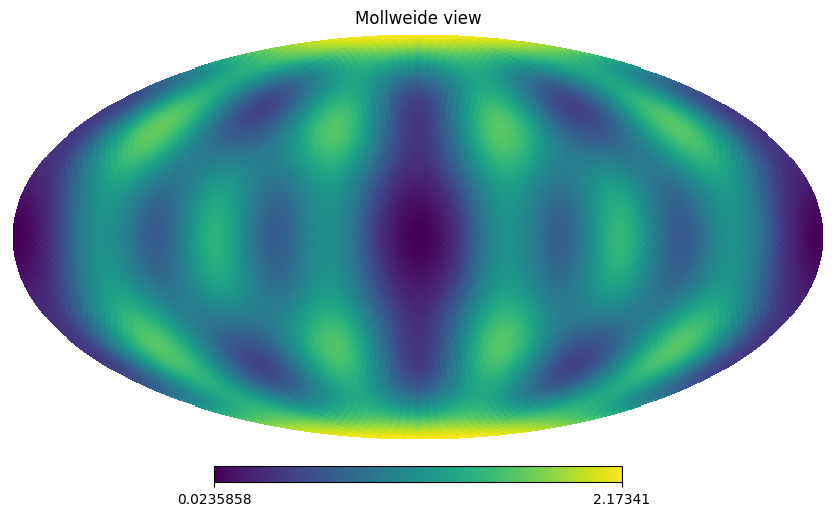

In [252]:
alms = hp.map2alm(np.asarray(actual_beam), lmax=8)
mapalm = hp.alm2map(alms, nside=nside)
hp.mollview(mapalm)

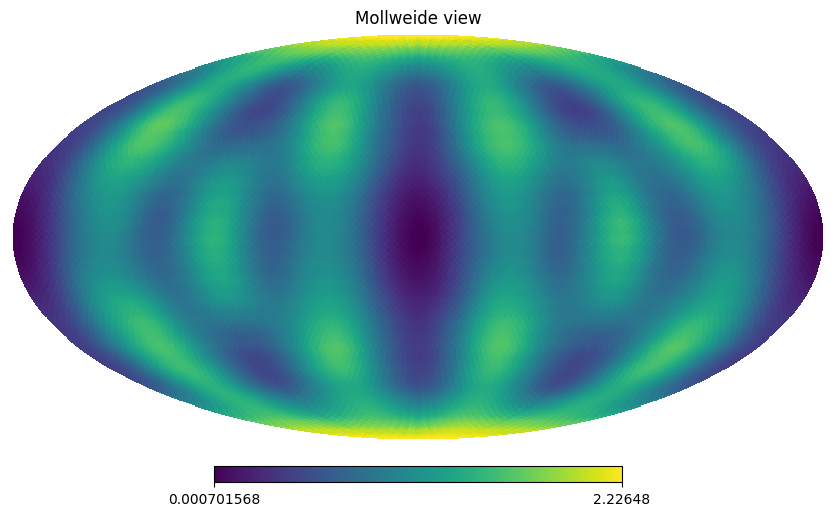

In [253]:
hp.mollview(actual_beam)

In [226]:
# el_inds = thetas + jnp.pi
# az_inds = phis - jnp.pi
# az_inds = phis  #+ jnp.pi/2 # BEST
# el_inds = thetas - jnp.pi/2 # BEST
# el_inds = thetas
delta_rx = 0
coord = jnp.array([0.0, -0.0, -1.0])
# el_ax = jnp.array([0.0, 1.0, 0.0], dtype=dtype_r)
# az_ax = jnp.array([0.0, 0.0, 1.0], dtype=dtype_r)
el_ax = jnp.array([1, 0, 0], dtype=dtype_r)
az_ax = jnp.array([0, 0, 1], dtype=dtype_r)

# coord = jnp.array([1.0,-0.0,-0.0]) ### best
# el_ax = jnp.array([1, 0, 0], dtype=dtype_r) ### best
# az_ax = jnp.array([0, 0, 1], dtype=dtype_r) ### best axes, only makes a line but fits data the best

# rx = RotatingAntenna(beam_th=bowtie_theta_beam_100, beam_phi=bowtie_phi_beam_100, 
                     # az_ax=az_ax, el_ax=el_ax)
# rx = RotatingAntenna(beam_th=bowtie_theta_beam_100, beam_phi=bowtie_phi_beam_100, 
                     # az_ax=az_ax, el_ax=el_ax)
rx100 = RotatingAntenna(beam_x=rx_w_x100, beam_y=rx_w_y100, beam_z=rx_w_z100,
                     az_ax=az_ax, el_ax=el_ax)
rx250 = RotatingAntenna(beam_x=rx_w_x250, beam_y=rx_w_y250, beam_z=rx_w_z250,
                     az_ax=az_ax, el_ax=el_ax)
tx_cir = TransmitterAntenna(E1=1.0, E2=0.0, heading_top=coord, alpha=90)
# P_cir, arc_pxs, eth, eph, plf = simulate_powers_vmap_phase_Es(
#     rx=rx, tx=tx_cir,
#     # az=el_const, el=az_const,
#     # az=az_const, el=el_const,
#     az=az_inds, el=el_inds,
#     E1=0, E2=0, delta_rx=delta_rx
# )

### BEST
# P_cir, arc_pxs, eth, eph, plf, _, _= simulate_powers_vmap_phase_Es_cart_rx(
#     rx=rx, tx=tx_cir,
#     # az=el_const, el=az_const,
#     # az=az_const, el=el_const,
#     az=az_inds, el=el_inds,
#     E1=0, E2=0, delta_rx=delta_rx
# )

P_cir100, arc_pxs, eth100, eph100, plf100, wth100, wph100 = simulate_powers_vmap_phase_Es_cart_rx(
    rx=rx100, tx=tx_cir,
    az=az_inds, el=el_inds,
    delta_rx=delta_rx, tx_E_cart=tx_E_cart100, freq=100
)
P_cir250, arc_pxs, eth250, eph250, plf250, wth250, wph250 = simulate_powers_vmap_phase_Es_cart_rx(
    rx=rx250, tx=tx_cir,
    az=az_inds, el=el_inds,
    delta_rx=delta_rx, tx_E_cart=tx_E_cart250, freq=250
)
P_cir250_, arc_pxs, eth250_, eph250_, plf250_, wth250_, wph250_ = simulate_powers_vmap_phase_Es_cart_rx(
    rx=rx250, tx=tx_cir,
    az=az_inds, el=el_inds,
    delta_rx=delta_rx, tx_E_cart=tx_E_cart100, freq=250
)

# P_cir, arc_pxs, eth, eph, plf, gtot = simulate_powers_vmap_phase_Es_hfss_txrx(
#     rx=rx, tx=tx_cir,
#     # az=el_const, el=az_const,
#     # az=az_const, el=el_const,
#     az=az_inds, el=el_inds,
# )

# px_tx, th_tx, ph_tx = compute_px_tx(rx, tx_cir)

# P_cir, arc_pxs, Eth, Ephi, PLF, Gtot = simulate_powers_vmap_phase_Es_hfss_txrx(
#     rx, tx_cir, az_inds, el_inds,
#     jnp.int32(px_tx),
#     jnp.asarray(th_tx),
#     jnp.asarray(ph_tx),
#     tx_w_theta, tx_w_phi,
#     rx_w_theta, rx_w_phi,
#     K=1.0, C0=0.0
# )
# P_cir,  Eth, Ephi, PLF, Gtot = sim_bowtie_tx_other_rx_fixed(
#     rx, tx_cir, az_inds, el_inds,
#     rx_w_theta, rx_w_phi,
#     tx_w_theta, tx_w_phi
# )


Wpow = (wth.conj() * wth + wph.conj() * wph).real
Epow = (eth.conj() * eth + eph.conj() * eph).real * 1e-6 * K_E


lam = 3e8 / (250e6)
# free_space = (lam / (4*jnp.pi*10))**2
free_space = (lam / (4*jnp.pi*100))**2

mu0 = 12.566e-7
eps0 = 8.854e-12
eta0 = jnp.sqrt(mu0 / eps0)
Pinc = 1.0
K_E = 4 * jnp.pi / (2 * eta0 * Pinc)
# actual_beam = ((jnp.abs(rx_w_x*1e-3))**2 + (jnp.abs(rx_w_y*1e-3))**2 + (jnp.abs(rx_w_z*1e-3))**2)*K_E
actual_beam = ((jnp.abs(rx_w_x*1e-3))**2 + (jnp.abs(rx_w_y*1e-3))**2 + (jnp.abs(rx_w_z*1e-3))**2)*K_E

# beam_proj(arc_pxs, P_cir, vmin=None, vmax=None, rot=(0, 0, 0))
# beam_proj(arc_pxs, P_cir/(plf*Epow*free_space), vmin=None, vmax=None, rot=(0, 0, 0))
# beam_proj(arc_pxs, actual_beam[arc_pxs], vmin=None, vmax=None, rot=(0, 0, 0))
# beam_proj(arc_pxs, P_meas, vmin=None, vmax=None, rot=(0, 0, 0))
# beam_proj(arc_pxs, plf, vmin=None, vmax=None, rot=(0, 0, 0))
# beam_proj(arc_pxs, Wpow, vmin=None, vmax=None, rot=(0, 0, 0))
# beam_proj(arc_pxs, Epow, vmin=None, vmax=None, rot=(0, 0, 0))

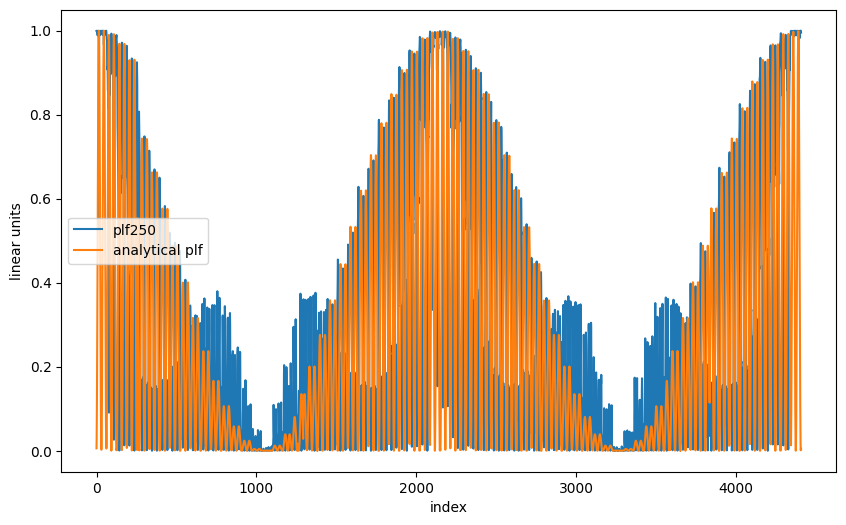

In [308]:
analytical_plf = (jnp.cos(az_inds)**2 * jnp.sin(el_inds)**2)
# analytical_plf = jnp.cos(el_inds)**2 * jnp.sin(az_inds)**2
plt.figure(figsize=(10, 6))
# plt.plot(plf100, label='plf100')
plt.plot(plf250,  label='plf250')
# plt.plot(plf250_, ls='--',  label='plf250 w 100E')
# plt.plot(P_cir250, label='sim')
# plt.plot(P_cir250_, label='sim w 100E')
# plt.plot(plf, label='plf')
plt.plot(analytical_plf, label='analytical plf')
plt.xlabel('index')
plt.ylabel('linear units')
# plt.ylabel('log units')
# plt.xlim(0, 2000)
plt.legend()
# plt.savefig('plots_3_20/sims100MHz_log')
plt.show()

# beam_proj(arc_pxs, P_cir, vmin=None, vmax=None)
# beam_proj(arc_pxs, P_meas, vmin=None, vmax=None)

<Figure size 1000x600 with 0 Axes>

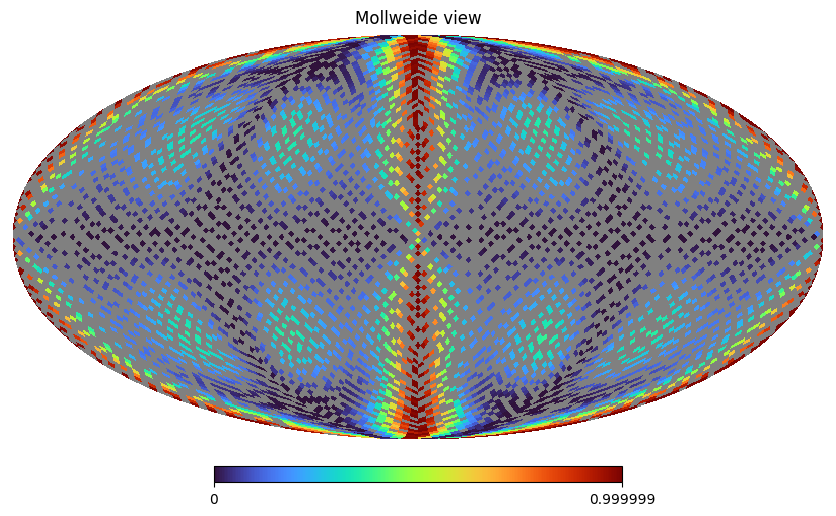

<Figure size 1000x600 with 0 Axes>

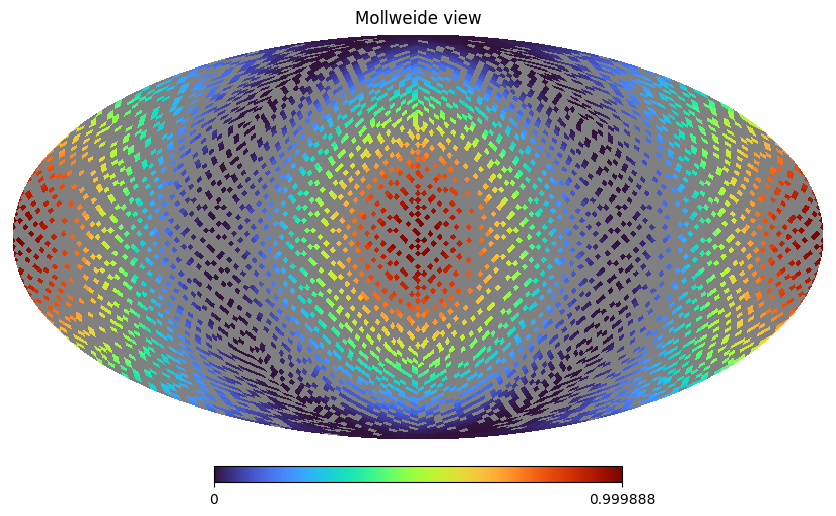

In [194]:
beam_proj(arc_pxs, plf, vmax=None)
beam_proj(arc_pxs, analytical_plf, vmax=None, rot=(0,0,0))

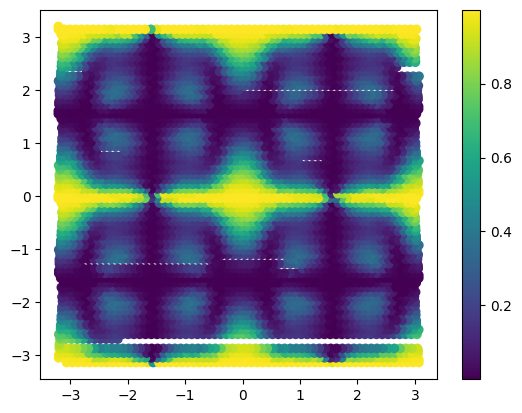

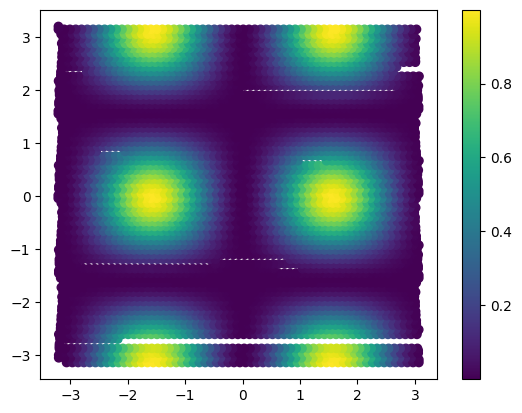

In [180]:
plt.figure()
plt.scatter(el_inds, az_inds, c=plf)
plt.colorbar()
plt.show()
plt.figure()
plt.scatter(el_inds, az_inds, c=analytical_plf)
plt.colorbar()
plt.show()

In [298]:
import jax
import jax.numpy as jnp
from jax.scipy.special import sph_harm
from jax.example_libraries import optimizers

def lm_list(lmax: int):
    ls = []
    ms = []
    for l in range(lmax + 1):
        for m in range(-l, l + 1):
            ls.append(l)
            ms.append(m)
    return jnp.array(ls, dtype=jnp.int32), jnp.array(ms, dtype=jnp.int32)

def build_sh_matrix(ths, phis, lmax: int):
    """
    Returns Y with shape (N, ncoef) where
      Y[i,k] = Y_{l_k,m_k}(ths[i], phis[i])
    """
    ths = jnp.asarray(ths)
    phis = jnp.asarray(phis)

    ls, ms = lm_list(lmax)
    N = ths.shape[0]
    ncoef = ls.shape[0]

    def eval_one(l, m):
        n = jnp.full((N,), l, dtype=jnp.int32)
        mm = jnp.full((N,), m, dtype=jnp.int32)
        # sph_harm(n, m, theta, phi)
        return sph_harm(n, mm, ths, phis, n_max=lmax)  # (N,), complex

    Y_lm = jax.vmap(eval_one)(ls, ms)        # (ncoef, N)
    Y = jnp.swapaxes(Y_lm, 0, 1)             # (N, ncoef)
    return Y, (ls, ms)

def precompute_incident(rx, tx, az, el, tx_E_cart, freq):
    # geometry
    Rs, ths, phis, pxs = px_th_ph_vmapped(rx, tx, az, el)

    th_hat  = rx.th_hat(ths, phis)   # (N,3)
    phi_hat = rx.phi_hat(ths, phis)  # (N,3)

    # TX field in RX-fixed frame per sample:
    tx_E_cart = jnp.asarray(tx_E_cart)
    # inv(R) @ v = R^T @ v for rotation matrices
    Es = jnp.einsum('nij,j->ni', jnp.swapaxes(Rs, -1, -2), tx_E_cart)  # (N,3)

    # project onto local spherical basis
    Eth  = jnp.einsum('ij,ij->i', jnp.conj(th_hat),  Es)
    Ephi = jnp.einsum('ij,ij->i', jnp.conj(phi_hat), Es)

    # incident polarization normalization
    Epow = (Eth.conj() * Eth + Ephi.conj() * Ephi).real
    En = jnp.sqrt(jnp.maximum(Epow, 1e-30))
    pinc_th  = Eth  / En
    pinc_phi = Ephi / En

    # constants (copied from your code)
    mu0 = 12.566e-7
    eps0 = 8.854e-12
    eta0 = jnp.sqrt(mu0 / eps0)
    Pinc = 1.0
    K_E = 4 * jnp.pi / (2 * eta0 * Pinc)

    # your conversion to "gain-like" Epow
    Epow_gain = Epow * 1e-6 * K_E

    lam = 3e8 / (freq * 1e6)
    free_space = (lam / (4 * jnp.pi * 100.0))**2

    # this multiplies (Gtot * PLF)
    Efac = Epow_gain * free_space  # (N,)

    return dict(
        ths=ths, phis=phis,
        th_hat=th_hat, phi_hat=phi_hat,
        pinc_th=pinc_th, pinc_phi=pinc_phi,
        K_E=K_E,
        Efac=Efac,
        pxs=pxs,
    )

def params_to_coeffs(params):
    """
    params: (3, ncoef, 2) real
    returns cx,cy,cz each (ncoef,) complex
    """
    re = params[..., 0]
    im = params[..., 1]
    c = re + 1j * im
    cx, cy, cz = c[0], c[1], c[2]
    return cx, cy, cz

def predict_power_from_sh_params(params, pre, Y):
    """
    params -> predicted P for all samples
    """
    cx, cy, cz = params_to_coeffs(params)

    # Evaluate cartesian beam at sampled directions
    wx = Y @ cx   # (N,)
    wy = Y @ cy
    wz = Y @ cz
    Wxyz = jnp.stack([wx, wy, wz], axis=-1)  # (N,3)

    th_hat  = pre["th_hat"]
    phi_hat = pre["phi_hat"]

    # convert sampled RX vector into local spherical components
    wth  = jnp.einsum('ij,ij->i', jnp.conj(th_hat),  Wxyz)
    wphi = jnp.einsum('ij,ij->i', jnp.conj(phi_hat), Wxyz)

    # polarization normalization (RX)
    Wpow = (wth.conj() * wth + wphi.conj() * wphi).real
    Wn = jnp.sqrt(jnp.maximum(Wpow, 1e-30))
    prx_th  = wth / Wn
    prx_phi = wphi / Wn

    # PLF
    inner = prx_th.conj() * pre["pinc_th"] + prx_phi.conj() * pre["pinc_phi"]
    PLF = (inner.conj() * inner).real

    # Gtot (copied from your code)
    Wpow_V2 = 1e-6 * Wpow
    Gtot = pre["K_E"] * Wpow_V2

    # final power
    P = pre["Efac"] * Gtot * PLF  # (N,)

    return P, Gtot, PLF, wth, wphi

def loss_fn(params, pre, Y, P_meas, mask=None,
            use_log=True,
            lam_coeff=1e-6,
            lam_gmax=1e-2,
            gmax=5.0):
    P_pred, Gtot, PLF, _, _ = predict_power_from_sh_params(params, pre, Y)

    if mask is None:
        w = 1.0
        denom = P_meas.size
    else:
        w = mask.astype(P_meas.dtype)
        denom = jnp.maximum(jnp.sum(w), 1.0)

    eps = 1e-30
    if use_log:
        r = (jnp.log(P_pred + eps) - jnp.log(P_meas + eps))
    else:
        r = (P_pred - P_meas)

    data = jnp.sum(w * (r * r)) / denom

    # L2 regularization on coefficients (helps pick a "small-energy" solution)
    reg = lam_coeff * jnp.mean(params * params)

    # Penalize violating total-gain max bound
    viol = jnp.maximum(Gtot - gmax, 0.0)
    gpen = lam_gmax * jnp.mean(viol * viol)

    return data + reg + gpen

def fit_rx_beam_sh(
    rx, tx, az, el,
    tx_E_cart, freq,
    P_meas,
    lmax_field=4,
    num_steps=5000,
    step_size=1e-2,
    seed=0,
    mask=None,
    use_log=True,
    lam_coeff=1e-6,
    lam_gmax=1e-2,
    gmax=5.0,
):
    # 1) Precompute geometry + incident terms
    pre = precompute_incident(rx, tx, az, el, tx_E_cart, freq)

    # 2) Build SH basis at sampled directions
    Y, (ls, ms) = build_sh_matrix(pre["ths"], pre["phis"], lmax_field)
    ncoef = Y.shape[1]

    # 3) Initialize params (3, ncoef, 2)
    key = jax.random.PRNGKey(seed)
    init_scale = 1e-3
    params0 = init_scale * jax.random.normal(key, (3, ncoef, 2), dtype=jnp.float32)

    # 4) Optimizer
    opt_init, opt_update, get_params = optimizers.adam(step_size)
    opt_state = opt_init(params0)

    # 5) One JITted step
    @jax.jit
    def step(i, opt_state):
        params = get_params(opt_state)
        L, grads = jax.value_and_grad(loss_fn)(
            params, pre, Y, P_meas,
            mask=mask,
            use_log=use_log,
            lam_coeff=lam_coeff,
            lam_gmax=lam_gmax,
            gmax=gmax
        )
        opt_state = opt_update(i, grads, opt_state)
        return opt_state, L

    # 6) Loop
    losses = []
    for i in range(num_steps):
        opt_state, L = step(i, opt_state)
        if (i % 200) == 0:
            losses.append(L)

    params_hat = get_params(opt_state)

    # optional: compute final predicted outputs
    P_hat, Gtot_hat, PLF_hat, wth_hat, wphi_hat = predict_power_from_sh_params(params_hat, pre, Y)

    return dict(
        params_hat=params_hat,
        P_hat=P_hat, Gtot_hat=Gtot_hat, PLF_hat=PLF_hat,
        wth_hat=wth_hat, wphi_hat=wphi_hat,
        losses=jnp.array(losses),
        Y=Y, pre=pre, ls=ls, ms=ms,
    )

fit = fit_rx_beam_sh(
    rx=rx100, tx=tx_cir,
    az=az_inds, el=el_inds,
    tx_E_cart=tx_E_cart100, freq=100,
    P_meas=P_cir100,
    lmax_field=4,
    num_steps=10000,
    step_size=1e-2,
    seed=0,
    use_log=True,
    lam_coeff=1e-6,
    lam_gmax=1e-2,
    gmax=2.3
)

P_hat   = fit["P_hat"]
Gtot_hat = fit["Gtot_hat"]
PLF_hat  = fit["PLF_hat"]

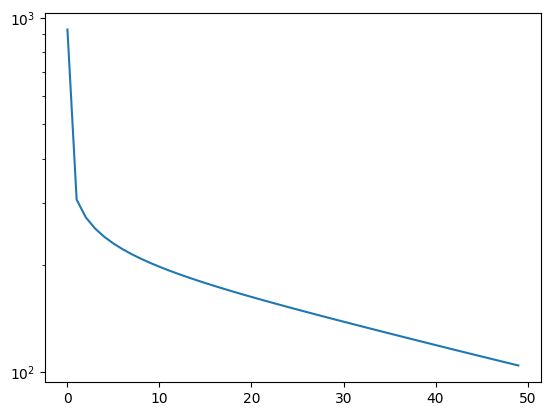

In [299]:
plt.figure()
plt.semilogy(fit['losses'])
plt.show()

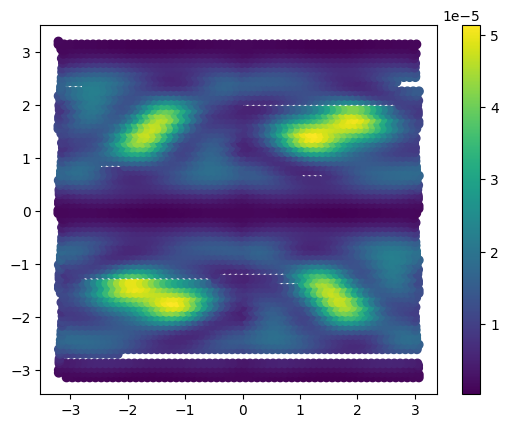

In [300]:
plt.figure()
plt.scatter(el_inds, az_inds, c=Gtot_hat)
plt.colorbar()
plt.show()